# Spatiotemporal Correlation Analysis

This notebook analyzes how inter-channel correlations in ECoG signals change through time,
and how this depends on the window length used for correlation computation.

The analysis:
1. Discovers all sessions in BIDS_ROOT
2. For each session, loads the ECoG signal
3. Computes pairwise channel correlations in sliding time windows
4. Visualizes how correlations evolve with different window lengths

In [1]:
import os
import glob
import re
from pathlib import Path
import h5py
from temporaldata import Data

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Configuration

In [2]:
BIDS_ROOT = "/network/projects/neuro-galaxy/data/processed/neurosoft_minipigs_2026"

# Analysis parameters (modify these to explore different settings)
subj_id = "sub-05"
window_lengths_seconds = [0.5, 1.0, 15, 30] #1.0, 2.0, 5.0]  # Different window lengths to test
overlap_fraction = 0.5  # Fraction of overlap between windows (0 = no overlap, 0.5 = 50%)
sessions_to_process = "all"  # "all" or list like ["sub-03_ses-01", "sub-03_ses-06"]
correlation_method = "pearson"  # Type of correlation ('pearson', 'spearman')
exclude_channel_types = ["misc"]  # Channel types to exclude from correlation analysis

# Display settings
plot_individual_correlations = True  # Plot correlation matrices for selected windows
selected_window_indices = [0, -1]  # Which windows to plot (first and last)

## 1. Session Discovery

In [3]:
def discover_sessions(bids_root, subj_id=None):
    """
    Discover all sessions in BIDS_ROOT by globbing for .h5 files and parsing BIDS filenames.
    Groups files by session and acquisition type (LH/RH), excluding filtered files.
    
    Returns:
        dict: Mapping of session_id with acquisition type (e.g., "sub-03_ses-01_acq_LH") 
              to list of H5 files (non-filtered only)
    """
    h5_files = glob.glob(os.path.join(bids_root, "*.h5"))
    
    sessions = {}
    # Match pattern: sub-XX_ses-YY and capture acquisition type (acq-LH or acq-RH)
    pattern = r"^(sub-\d+_ses-\d+)_.*_(acq-[LR]H).*\.h5$"
    
    for filepath in h5_files:
        filename = os.path.basename(filepath)
        
        # Skip filtered files
        if "filtered" in filename:
            continue
            
        match = re.match(pattern, filename)

        if subj_id is not None:
            if subj_id not in filename:
                continue
                
        if match:
            base_session_id = match.group(1)
            acq_type = match.group(2)  # e.g., "acq-LH" or "acq-RH"
            # Create session_id with acquisition type suffix
            session_id = f"{base_session_id}_{acq_type}"
            
            if session_id not in sessions:
                sessions[session_id] = []
            sessions[session_id].append(filepath)
    
    # Sort for consistency
    sessions = dict(sorted(sessions.items()))
    
    return sessions


sessions = discover_sessions(BIDS_ROOT, subj_id)
print(f"Found {len(sessions)} unique sessions:")
for session_id in sorted(sessions.keys()):
    print(f"  {session_id}: {len(sessions[session_id])} files")

# Filter sessions if specified
if sessions_to_process != "all":
    sessions = {k: v for k, v in sessions.items() if k in sessions_to_process}

Found 4 unique sessions:
  sub-05_ses-01_acq-LH: 1 files
  sub-05_ses-01_acq-RH: 1 files
  sub-05_ses-02_acq-LH: 1 files
  sub-05_ses-02_acq-RH: 1 files


## 2. Correlation Computation Functions

In [4]:
def compute_correlation_matrix(signal_window):
    """
    Compute correlation matrix for a signal window.
    
    Args:
        signal_window: Array of shape (time_samples, channels)
    
    Returns:
        corr_matrix: Correlation matrix of shape (channels, channels)
    """
    # Compute Pearson correlation
    corr_matrix = np.corrcoef(signal_window.T)
    return corr_matrix


def compute_sliding_correlations(signal, sampling_rate, window_length_seconds, overlap_fraction=0.5):
    """
    Compute correlation matrices for sliding windows of a signal.
    
    Args:
        signal: ECoG signal of shape (time_samples, channels)
        sampling_rate: Sampling rate in Hz
        window_length_seconds: Length of each window in seconds
        overlap_fraction: Fraction of overlap between consecutive windows (0-1)
    
    Returns:
        dict with:
            - 'correlations': List of correlation matrices (channels x channels)
            - 'window_times': Center time of each window in seconds
            - 'window_indices': (start_sample, end_sample) for each window
    """
    window_samples = int(window_length_seconds * sampling_rate)
    step_samples = int(window_samples * (1 - overlap_fraction))
    
    n_samples = signal.shape[0]
    n_channels = signal.shape[1]
    
    correlations = []
    window_times = []
    window_indices = []
    
    start_idx = 0
    while start_idx + window_samples <= n_samples:
        end_idx = start_idx + window_samples
        
        # Extract window and compute correlation
        window_signal = signal[start_idx:end_idx, :]
        corr_matrix = compute_correlation_matrix(window_signal)
        
        correlations.append(corr_matrix)
        
        # Compute center time of window
        center_time = (start_idx + end_idx) / 2 / sampling_rate
        window_times.append(center_time)
        window_indices.append((start_idx, end_idx))
        
        start_idx += step_samples
    
    return {
        'correlations': correlations,
        'window_times': np.array(window_times),
        'window_indices': window_indices,
        'window_length_seconds': window_length_seconds,
        'n_windows': len(correlations)
    }


def extract_correlation_statistics(correlations):
    """
    Extract summary statistics from correlation matrices.
    
    Args:
        correlations: List of correlation matrices
    
    Returns:
        dict with arrays of:
            - 'mean_corr': Mean correlation (excluding diagonal) for each window
            - 'std_corr': Std of correlation for each window
            - 'max_corr': Max correlation for each window
            - 'min_corr': Min correlation for each window
    """
    n_windows = len(correlations)
    stats_dict = {
        'mean_corr': np.zeros(n_windows),
        'std_corr': np.zeros(n_windows),
        'max_corr': np.zeros(n_windows),
        'min_corr': np.zeros(n_windows),
    }
    
    for i, corr_matrix in enumerate(correlations):
        # Get upper triangle (excluding diagonal)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        corr_values = corr_matrix[mask]
        
        stats_dict['mean_corr'][i] = np.mean(corr_values)
        stats_dict['std_corr'][i] = np.std(corr_values)
        stats_dict['max_corr'][i] = np.max(corr_values)
        stats_dict['min_corr'][i] = np.min(corr_values)
    
    return stats_dict


print("Correlation computation functions defined.")

Correlation computation functions defined.


## 3. Load Sessions and Process

In [5]:
def load_session_data(h5_files):
    """
    Load and concatenate ECoG data from all H5 files in a session/acquisition group.
    
    Args:
        h5_files: List of H5 file paths for a session (all should have same channels/sampling rate)
    
    Returns:
        dict with 'signal', 'sampling_rate', 'channel_names', 'channel_types'
    """
    if not h5_files:
        raise ValueError("No H5 files provided")
    
    signals = []
    sampling_rate = None
    channel_names = None
    channel_types = None
    
    for h5_file in h5_files:
        print(f"  Loading {os.path.basename(h5_file)}...")

        with h5py.File(h5_file, "r") as f:
            data = Data.from_hdf5(f, lazy=False)
            
            # Extract signal and metadata
            signal = data.ecog.signal
            signals.append(signal)
            
            # Get channel info from first file (all should be identical)
            if channel_names is None:
                channel_names = data.channels.id
                channel_types = data.channels.type
            
            # Get sampling rate from first file (all should be identical)
            if sampling_rate is None:
                if hasattr(data.ecog, 'sampling_rate'):
                    sampling_rate = float(data.ecog.sampling_rate)
                elif 'filtered' in h5_file:
                    sampling_rate = 500.0
                    print(f"    WARNING: Sampling rate not found in metadata, using {sampling_rate} Hz")
                else:
                    sampling_rate = 2000.0
                    print(f"    WARNING: Sampling rate not found in metadata, using {sampling_rate} Hz")
    
    # Concatenate all signals along time axis
    concatenated_signal = np.concatenate(signals, axis=0)
    
    return {
        'signal': concatenated_signal,
        'sampling_rate': sampling_rate,
        'channel_names': channel_names,
        'channel_types': channel_types,
    }


def filter_ecog_channels(data_dict, exclude_types=None):
    """
    Filter to keep only ECoG channels, excluding specified types.
    
    Args:
        data_dict: Dict with 'signal', 'channel_names', 'channel_types'
        exclude_types: List of channel types to exclude (e.g., ['misc'])
    
    Returns:
        Filtered data_dict
    """
    if exclude_types is None:
        exclude_types = []
    
    mask = np.array([ch_type.lower() not in exclude_types for ch_type in data_dict['channel_types']])
    
    data_dict['signal'] = data_dict['signal'][:, mask]
    data_dict['channel_names'] = data_dict['channel_names'][mask]
    data_dict['channel_types'] = data_dict['channel_types'][mask]
    
    return data_dict


print("Data loading functions defined.")

Data loading functions defined.


In [6]:
# Process all sessions with all window lengths
results = {}

for session_id in sorted(sessions.keys()):
    
    h5_files = sessions[session_id]
    
    print(f"\nProcessing {session_id}...")
    
    # Load session data (will concatenate all files for this session/acquisition)
    data_dict = load_session_data(h5_files)
    data_dict = filter_ecog_channels(data_dict, exclude_types=exclude_channel_types)
    
    print(f"  Signal shape: {data_dict['signal'].shape}")
    print(f"  Channels: {len(data_dict['channel_names'])} ECoG channels")
    print(f"  Sampling rate: {data_dict['sampling_rate']} Hz")
    
    results[session_id] = {}
    
    # Compute correlations for each window length
    for window_length in window_lengths_seconds:
        print(f"  Computing correlations for window_length={window_length}s...")
        
        corr_result = compute_sliding_correlations(
            signal=data_dict['signal'],
            sampling_rate=data_dict['sampling_rate'],
            window_length_seconds=window_length,
            overlap_fraction=overlap_fraction
        )
        
        # Extract statistics
        stats_result = extract_correlation_statistics(corr_result['correlations'])
        
        results[session_id][window_length] = {
            'correlations': corr_result['correlations'],
            'window_times': corr_result['window_times'],
            'window_indices': corr_result['window_indices'],
            'n_windows': corr_result['n_windows'],
            'stats': stats_result,
            'sampling_rate': data_dict['sampling_rate'],
            'channel_names': data_dict['channel_names'],
            'channel_types': data_dict['channel_types'],
        }
        
        print(f"    Generated {corr_result['n_windows']} windows")

print("\nProcessing complete!")


Processing sub-05_ses-01_acq-LH...
  Loading sub-05_ses-01_task-AcousStim_acq-LH_desc-raw.h5...


  Signal shape: (4513955, 18)
  Channels: 18 ECoG channels
  Sampling rate: 2000.0 Hz
  Computing correlations for window_length=0.5s...
    Generated 9026 windows
  Computing correlations for window_length=1.0s...
    Generated 4512 windows
  Computing correlations for window_length=15s...
    Generated 299 windows
  Computing correlations for window_length=30s...
    Generated 149 windows

Processing sub-05_ses-01_acq-RH...
  Loading sub-05_ses-01_task-AcousStim_acq-RH_desc-raw.h5...
  Signal shape: (4513955, 18)
  Channels: 18 ECoG channels
  Sampling rate: 2000.0 Hz
  Computing correlations for window_length=0.5s...


/home/mila/s/suarezul/research/repos/auditorydecoding/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mila/s/suarezul/research/repos/auditorydecoding/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    Generated 9026 windows
  Computing correlations for window_length=1.0s...
    Generated 4512 windows
  Computing correlations for window_length=15s...
    Generated 299 windows
  Computing correlations for window_length=30s...
    Generated 149 windows

Processing sub-05_ses-02_acq-LH...
  Loading sub-05_ses-02_task-AcousStim_acq-LH_desc-raw.h5...
  Signal shape: (3606800, 18)
  Channels: 18 ECoG channels
  Sampling rate: 2000.0 Hz
  Computing correlations for window_length=0.5s...
    Generated 7212 windows
  Computing correlations for window_length=1.0s...
    Generated 3605 windows
  Computing correlations for window_length=15s...
    Generated 239 windows
  Computing correlations for window_length=30s...
    Generated 119 windows

Processing sub-05_ses-02_acq-RH...
  Loading sub-05_ses-02_task-AcousStim_acq-RH_desc-raw.h5...
  Signal shape: (3606800, 18)
  Channels: 18 ECoG channels
  Sampling rate: 2000.0 Hz
  Computing correlations for window_length=0.5s...
    Generated 7212

## 4. Meta-Correlation Analysis: Temporal Dynamics of Correlation Structure

In [7]:
def extract_correlation_vector(corr_matrix):
    """
    Extract pairwise correlations as a vector from a correlation matrix.
    
    Args:
        corr_matrix: Square correlation matrix (channels x channels)
    
    Returns:
        1D array of upper triangular elements (excluding diagonal)
    """
    # Extract upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    return corr_matrix[mask]


def compute_meta_correlations(correlations):
    """
    Compute correlations between correlation-vectors across all time windows.
    This shows how similar the inter-channel correlation structure is between different time windows.
    
    Args:
        correlations: List of correlation matrices (one per time window)
    
    Returns:
        meta_corr_matrix: Window x Window matrix showing correlation similarity
        corr_vectors: (n_windows x n_pairwise_corrs) array of correlation vectors
    """
    n_windows = len(correlations)
    
    # Extract correlation vectors
    corr_vectors = np.array([extract_correlation_vector(c) for c in correlations])
    
    # Compute correlation between all pairs of correlation-vectors
    meta_corr_matrix = np.corrcoef(corr_vectors)
    
    return meta_corr_matrix, corr_vectors


print("Meta-correlation functions defined.")

Meta-correlation functions defined.


In [8]:
# Compute meta-correlations for all sessions and window lengths
meta_corr_results = {}

for session_id in sorted(results.keys()):
    meta_corr_results[session_id] = {}
    
    for window_length in sorted(window_lengths_seconds):
        result = results[session_id][window_length]
        correlations = result['correlations']
        
        # Compute meta-correlations
        meta_corr_matrix, corr_vectors = compute_meta_correlations(correlations)
        
        meta_corr_results[session_id][window_length] = {
            'meta_corr_matrix': meta_corr_matrix,
            'corr_vectors': corr_vectors,
            'window_times': result['window_times'],
            'n_windows': result['n_windows'],
        }

print("Meta-correlation computation complete!")

Meta-correlation computation complete!


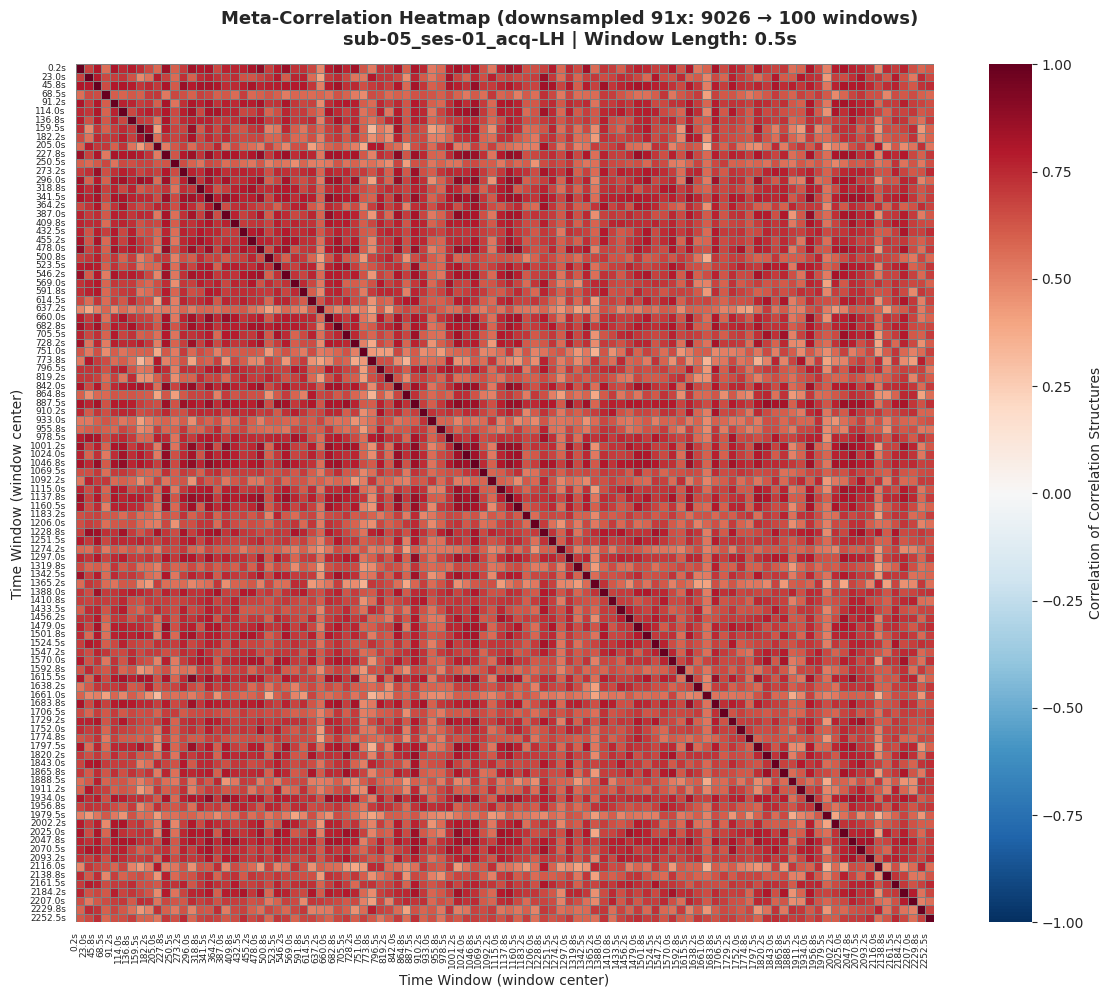

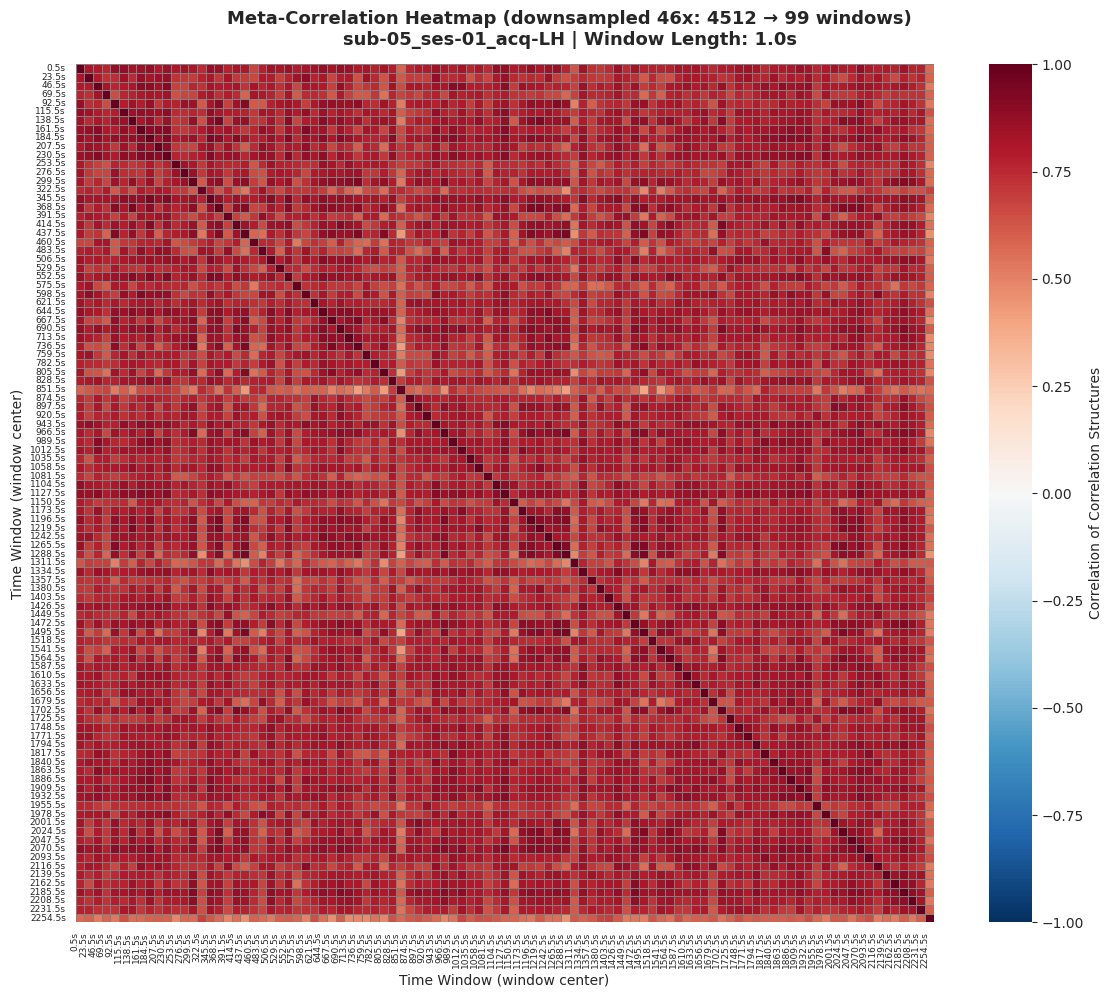

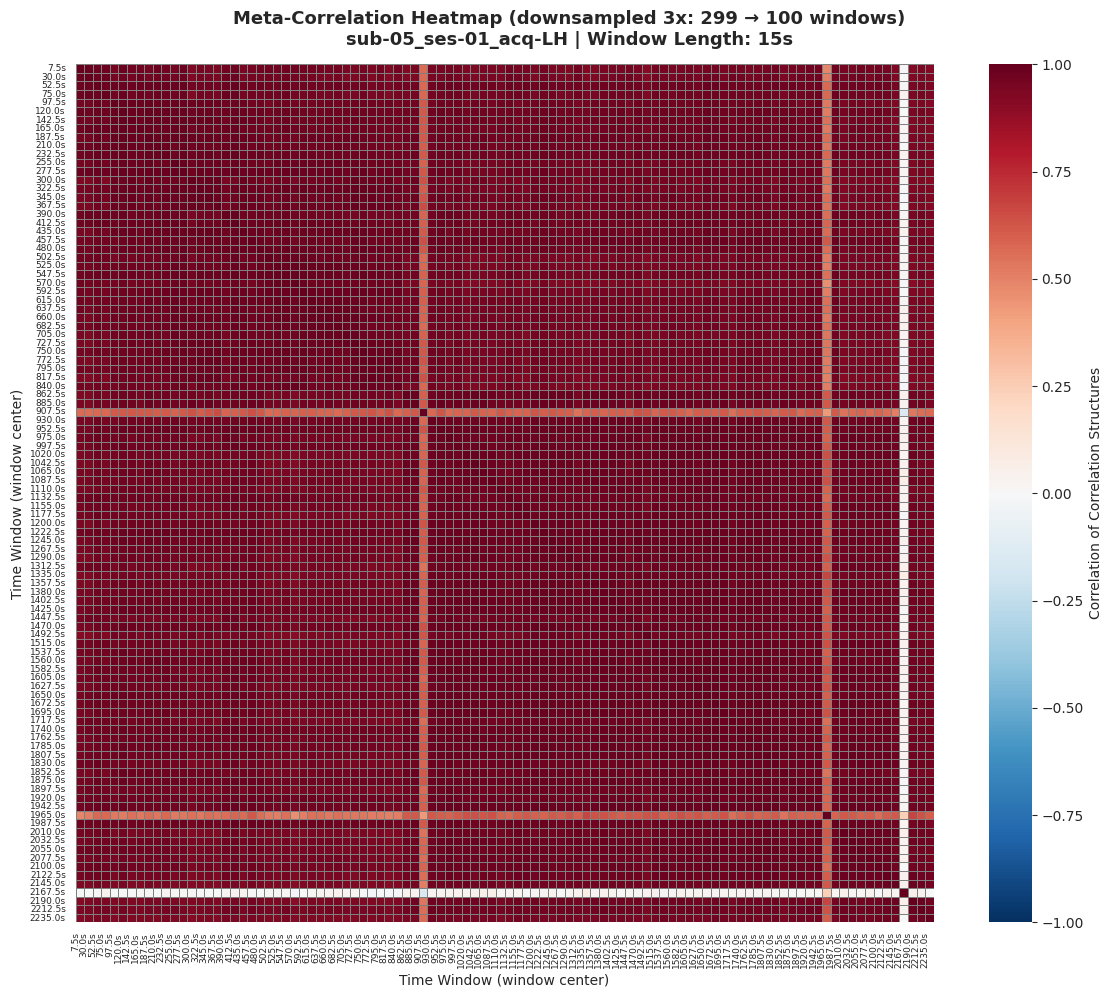

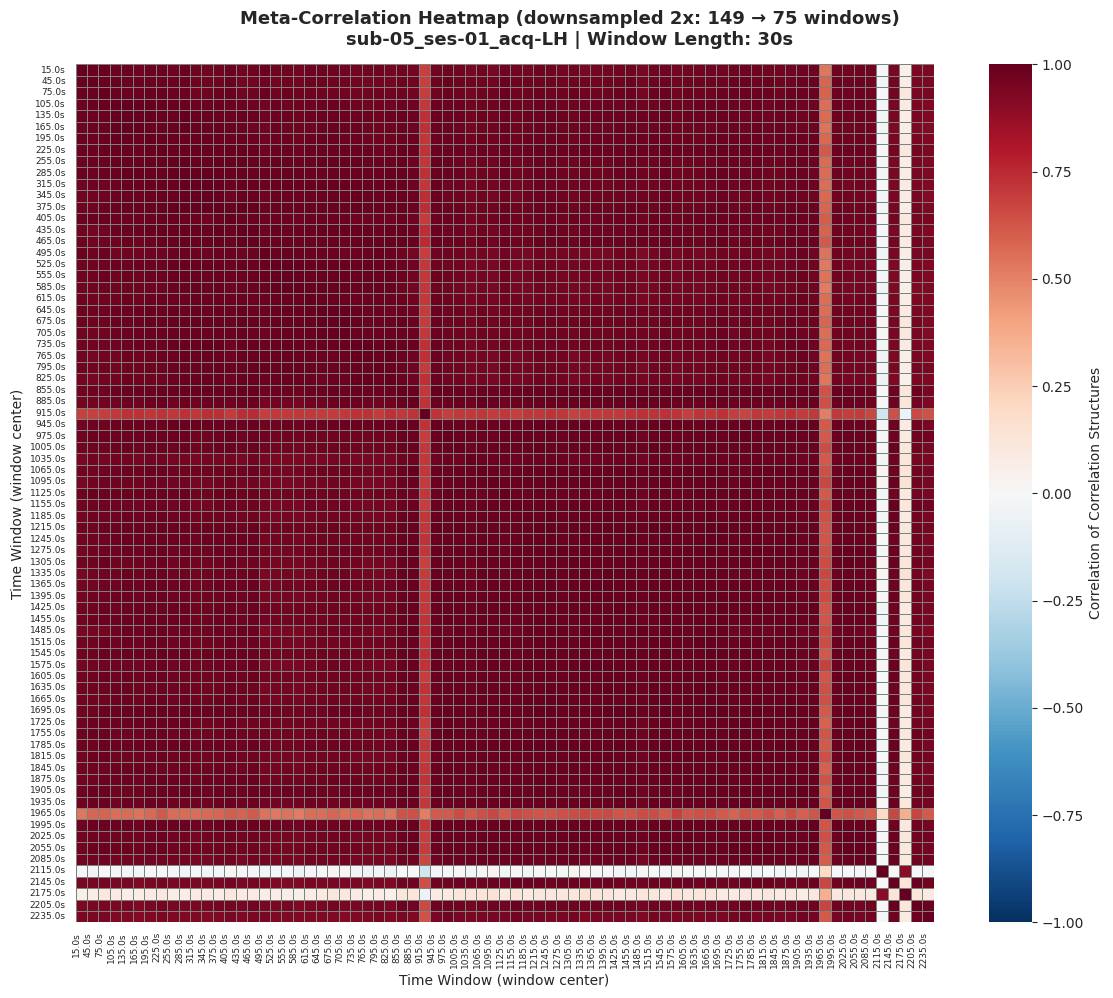

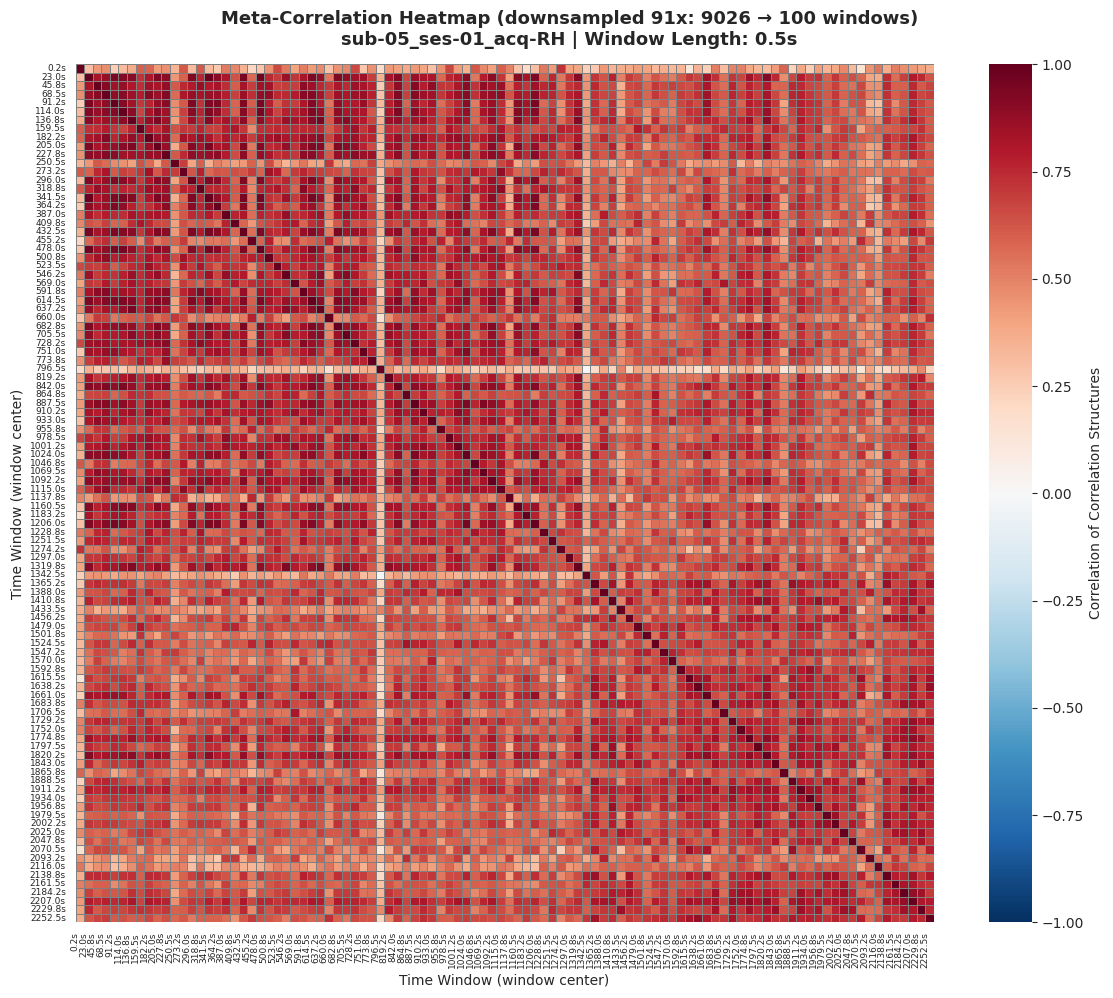

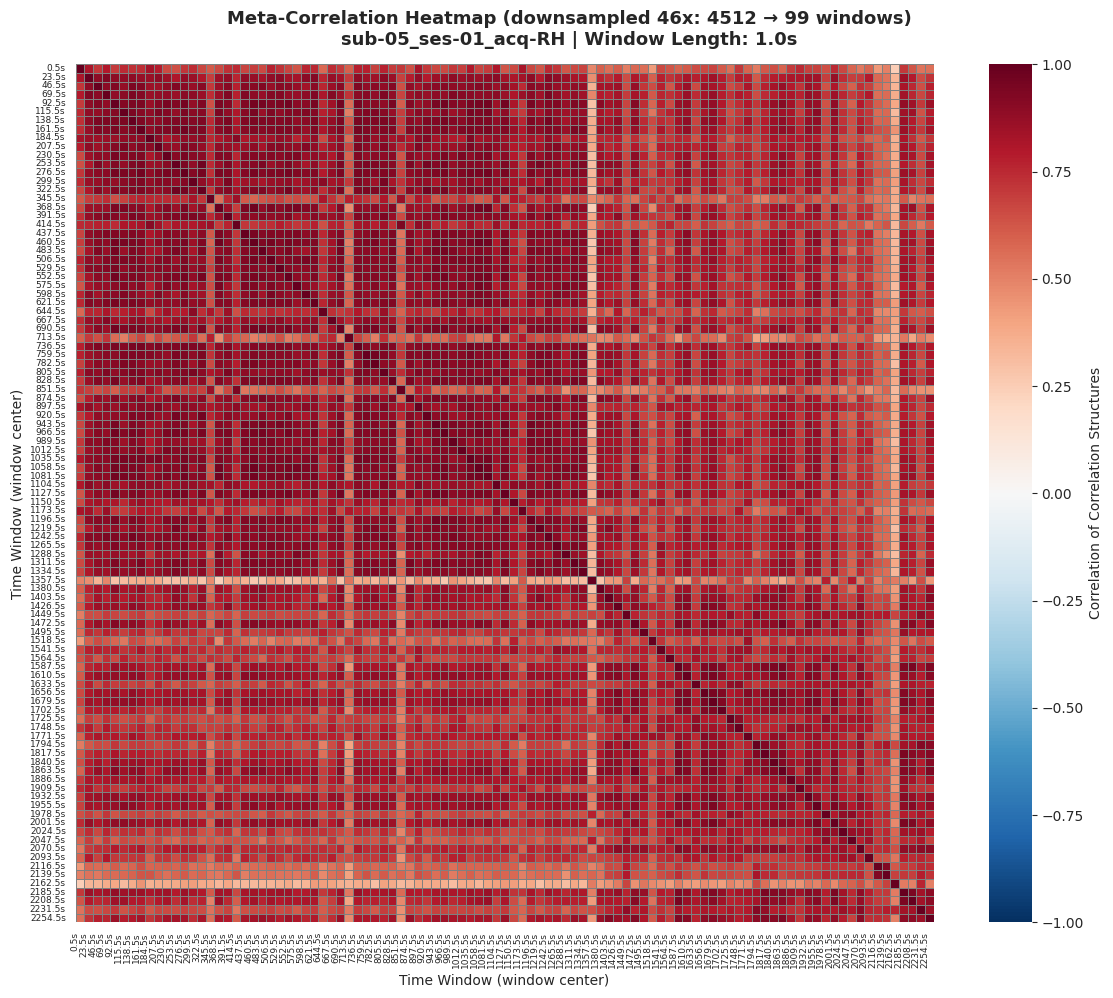

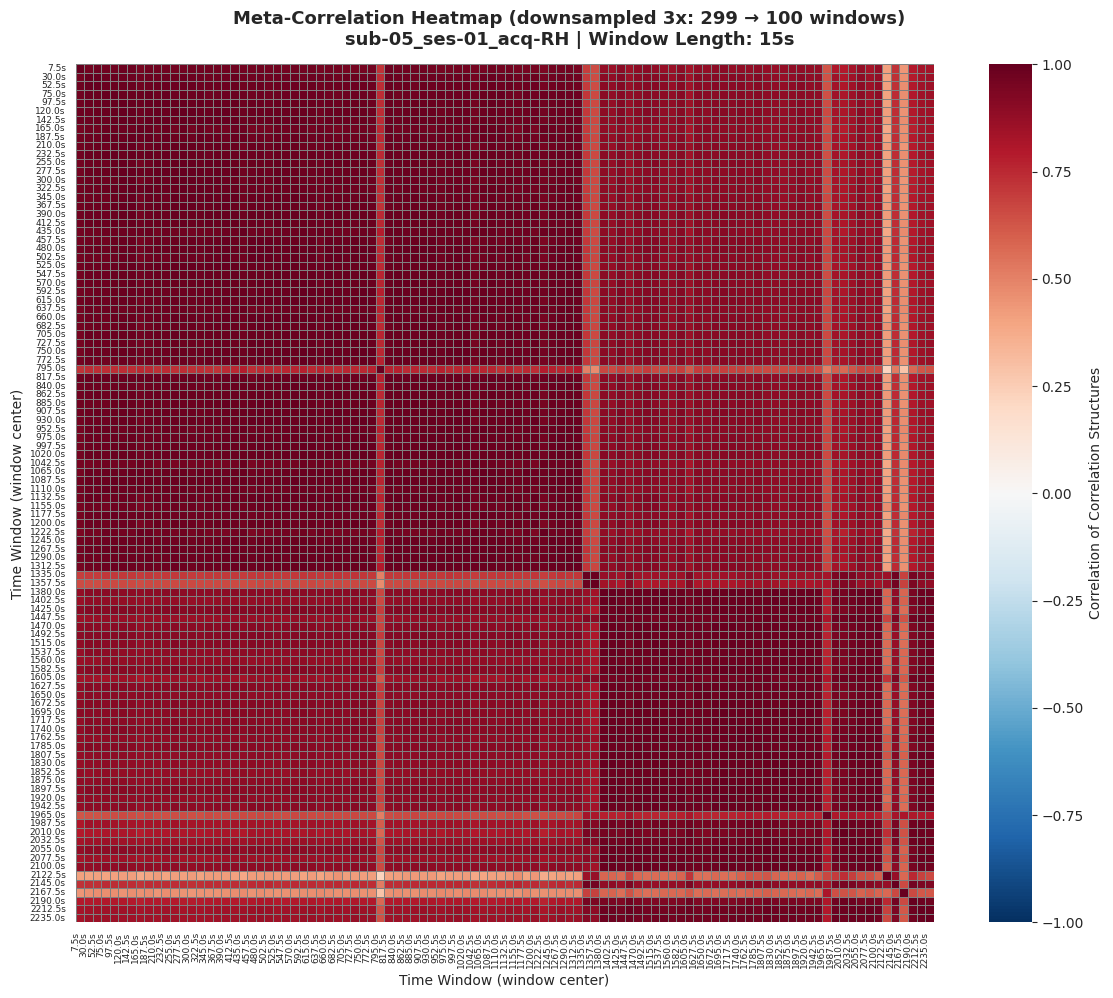

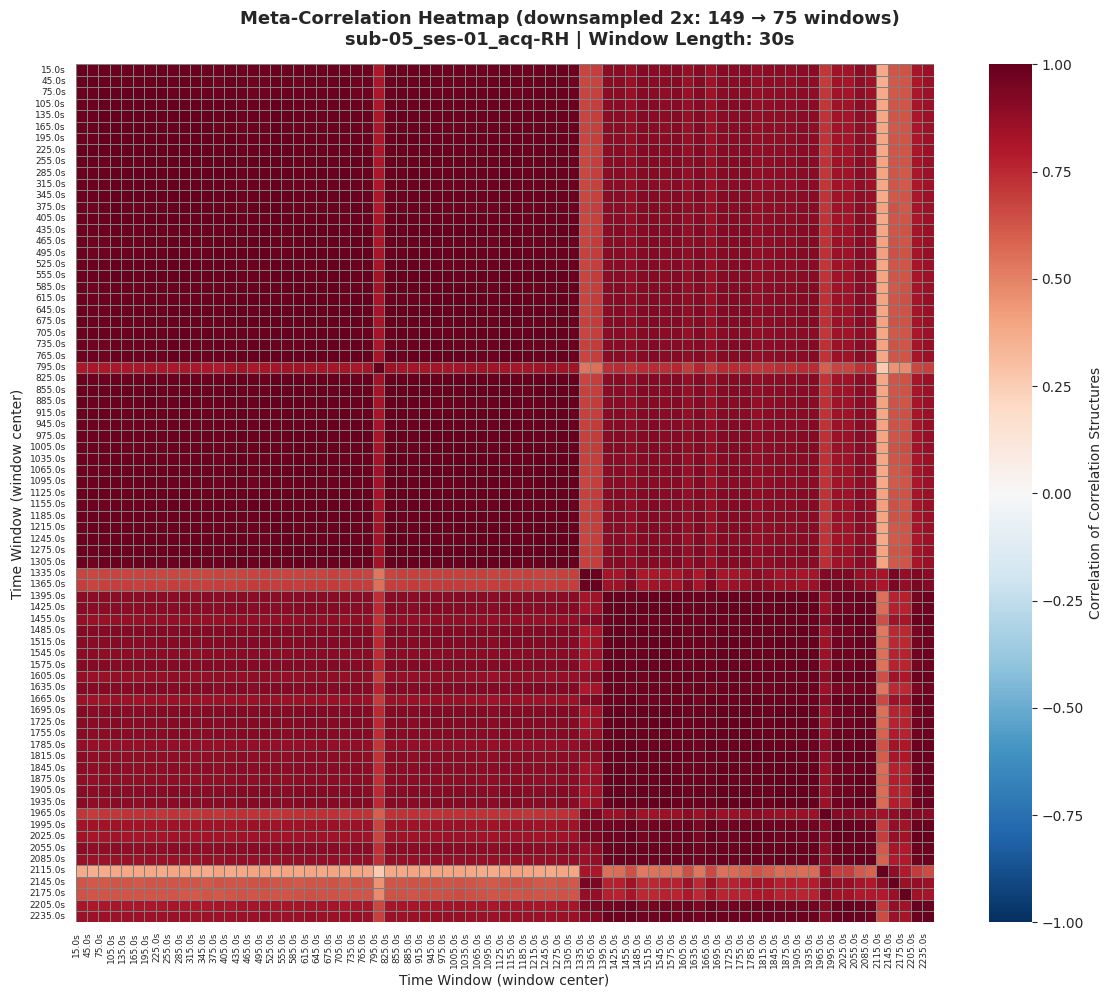

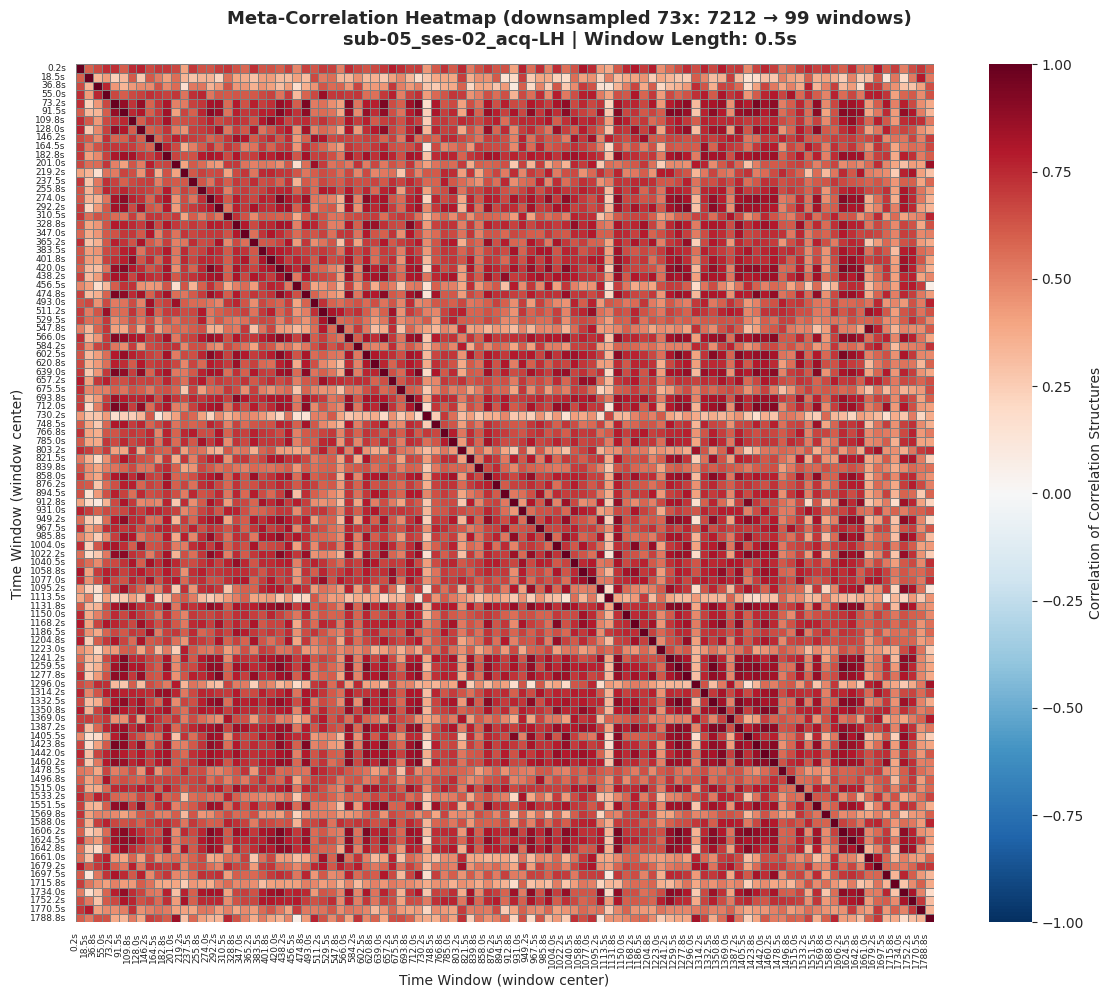

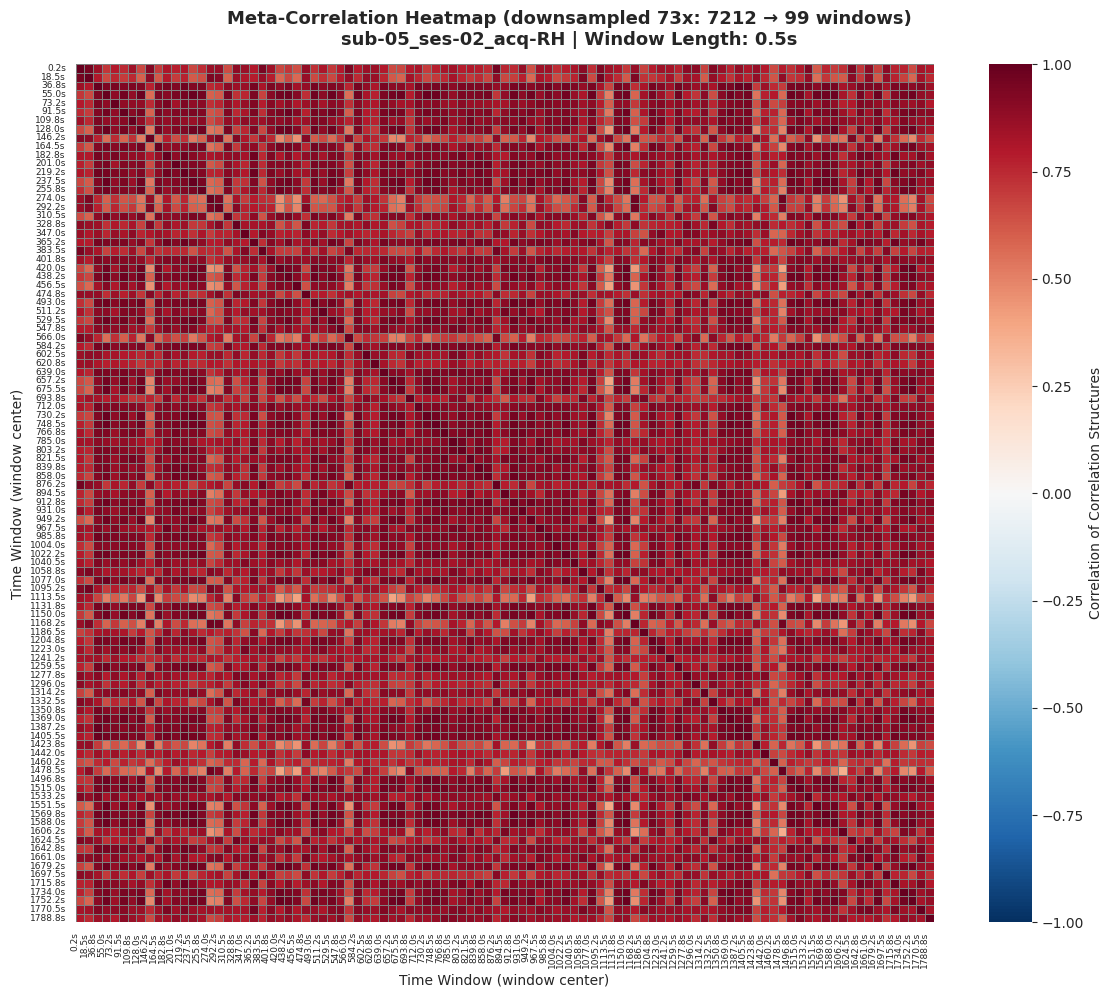

In [9]:
def plot_meta_correlation_heatmap(session_id, window_length, meta_corr_data, 
                                  window_step=None, max_windows_to_display=100, figsize=(12, 10)):
    """
    Plot a heatmap of meta-correlations (time window x time window) using seaborn.
    Shows how similar the inter-channel correlation structure is between different time points.
    
    Args:
        session_id: Session identifier
        window_length: Window length in seconds
        meta_corr_data: Meta-correlation data dict with 'meta_corr_matrix', 'window_times', 'n_windows'
        window_step: Step size for downsampling (1=all windows, 5=every 5th window, etc.)
                    If None, automatically calculates to keep matrix <= max_windows_to_display
        max_windows_to_display: Maximum windows to display per axis (auto-downsamples if exceeded)
        figsize: Figure size tuple
    """
    import seaborn as sns
    
    meta_corr_matrix = meta_corr_data['meta_corr_matrix']
    window_times = meta_corr_data['window_times']
    n_windows = meta_corr_data['n_windows']
    
    # Auto-calculate window_step if needed
    if window_step is None:
        if n_windows > max_windows_to_display:
            window_step = int(np.ceil(n_windows / max_windows_to_display))
        else:
            window_step = 1
    
    # Downsample the matrix if window_step > 1
    if window_step > 1:
        indices = np.arange(0, n_windows, window_step)
        meta_corr_matrix_display = meta_corr_matrix[np.ix_(indices, indices)]
        window_times_display = window_times[indices]
        downsampling_info = f" (downsampled {window_step}x: {n_windows} → {len(indices)} windows)"
    else:
        meta_corr_matrix_display = meta_corr_matrix
        window_times_display = window_times
        downsampling_info = ""
    
    n_display = len(window_times_display)
    
    # Create tick labels for time windows
    tick_labels = [f"{t:.1f}s" for t in window_times_display]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap using seaborn
    sns.heatmap(meta_corr_matrix_display, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=tick_labels, yticklabels=tick_labels,
                cbar_kws={'label': 'Correlation of Correlation Structures'},
                square=True, ax=ax, linewidths=0.5, linecolor='gray', annot=False)
    
    ax.set_xlabel('Time Window (window center)', fontsize=10)
    ax.set_ylabel('Time Window (window center)', fontsize=10)
    
    # Rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right', fontsize=6.5)
    plt.setp(ax.get_yticklabels(), ha='right', fontsize=6.5)
    
    title = f'Meta-Correlation Heatmap{downsampling_info}\n{session_id} | Window Length: {window_length}s'
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# Plot for all sessions and window lengths (with auto-downsampling for large matrices)
cont = 0
for session_id in sorted(meta_corr_results.keys()):
    for window_length in sorted(window_lengths_seconds):
        meta_corr_data = meta_corr_results[session_id][window_length]
        plot_meta_correlation_heatmap(session_id, window_length, meta_corr_data, 
                                     max_windows_to_display=100)
        
        cont += 1
        if cont > 8:
            break
        

### Interpretation Guide for Meta-Correlation Analysis

**Meta-Correlation Heatmap:**
- **High values (red) on diagonal**: Correlation structures are stable within each window (expected, = 1)
- **High values off-diagonal**: Different time windows have similar inter-channel correlation structures - indicates stable network dynamics
- **Low values off-diagonal**: Different time windows have different correlation structures - indicates changing network dynamics
- **Striped/banded patterns**: Indicate epochs where correlation structure is similar, suggesting task-related or state-related groupings

## 4. Visualization: Correlation Statistics Over Time

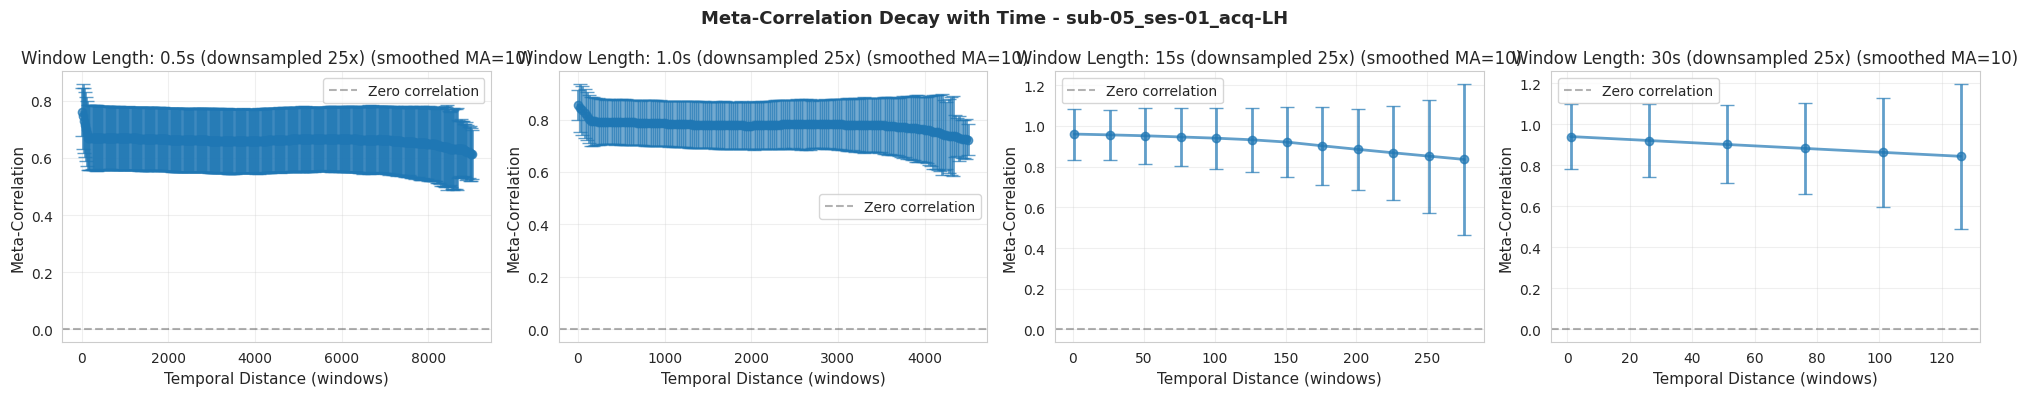

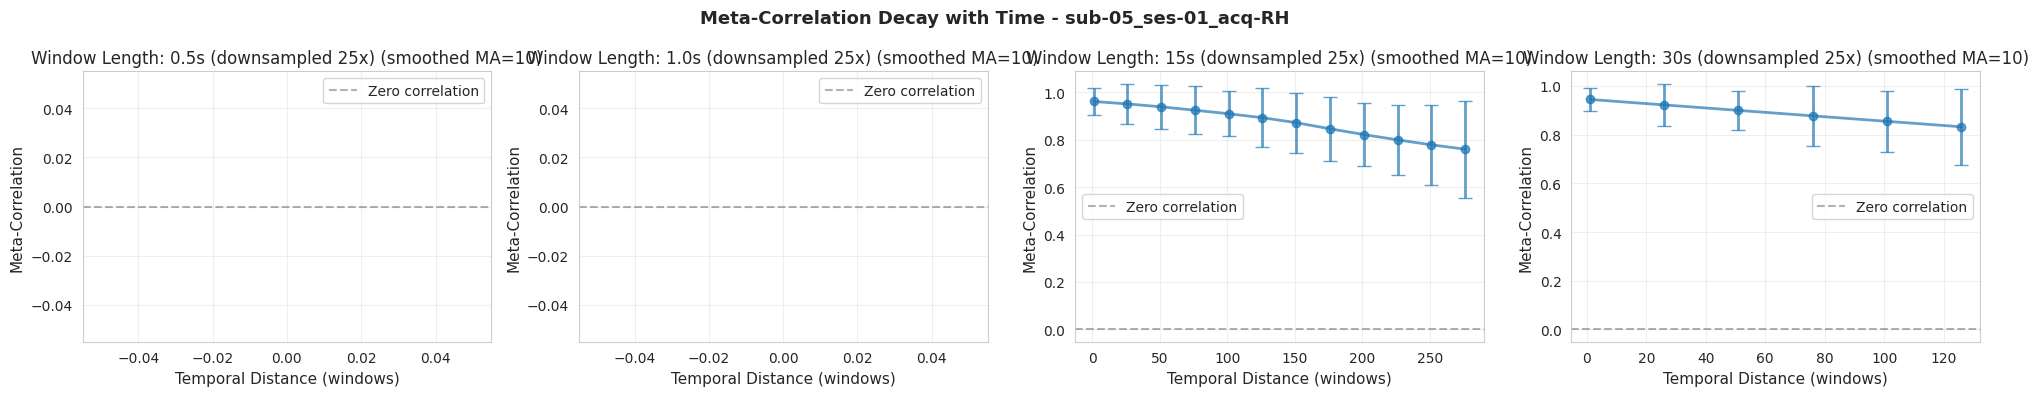

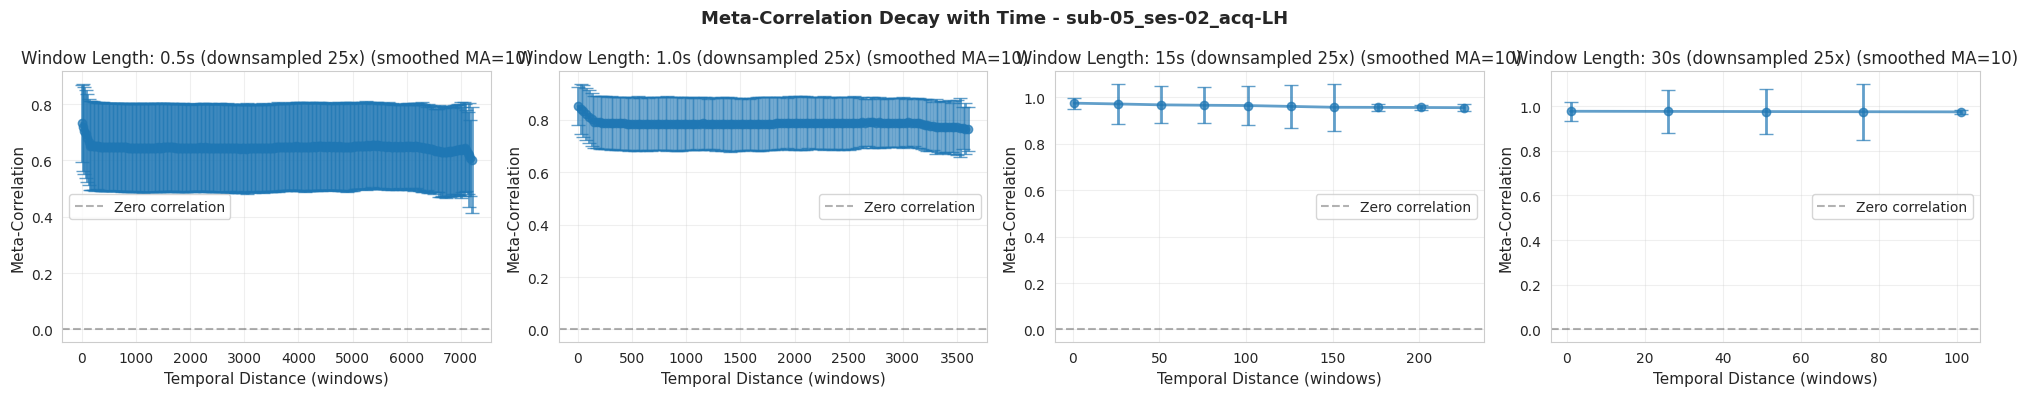

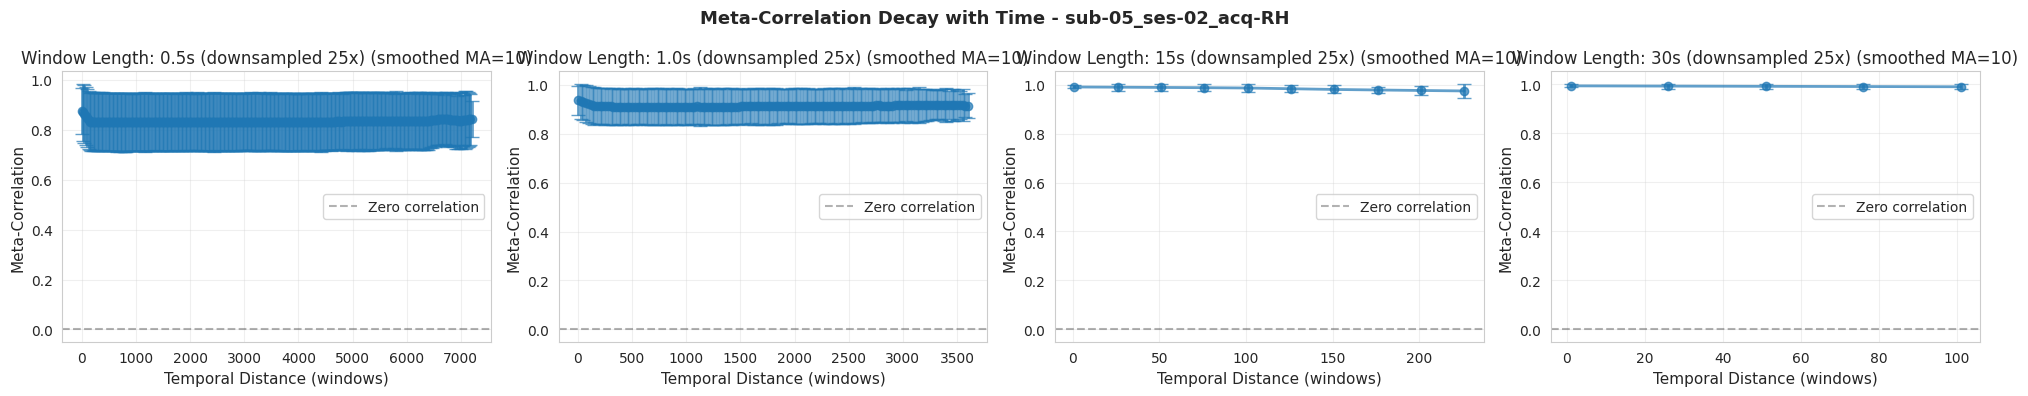

In [10]:
def plot_meta_correlation_decay(session_id, results_session, meta_corr_results_session, 
                                downsample_factor=1, smooth_window=None):
    """
    Plot how meta-correlation decays with temporal distance.
    This shows if correlation structures become more different over time.
    
    Args:
        session_id: Session identifier
        results_session: Results for this session
        meta_corr_results_session: Meta-correlation results for this session
        downsample_factor: Factor to downsample temporal distances (e.g., 5 = plot every 5th distance)
        smooth_window: Window size for moving average smoothing (e.g., 10). If None, no smoothing.
    """
    fig, axes = plt.subplots(1, len(window_lengths_seconds), figsize=(5*len(window_lengths_seconds), 4))
    
    if len(window_lengths_seconds) == 1:
        axes = [axes]
    
    for ax_idx, window_length in enumerate(sorted(window_lengths_seconds)):
        meta_corr_data = meta_corr_results_session[window_length]
        meta_corr_matrix = meta_corr_data['meta_corr_matrix']
        n_windows = meta_corr_data['n_windows']
        
        # Off-diagonal elements at different distances from diagonal
        distances = []
        off_diag_means = []
        off_diag_stds = []
        
        for d in range(1, n_windows):
            diag_slice = np.diag(meta_corr_matrix, k=d)
            if len(diag_slice) > 0:
                distances.append(d)
                off_diag_means.append(np.mean(diag_slice))
                off_diag_stds.append(np.std(diag_slice))
        
        distances = np.array(distances)
        off_diag_means = np.array(off_diag_means)
        off_diag_stds = np.array(off_diag_stds)
        
        # Apply downsampling if requested
        if downsample_factor > 1:
            indices = np.arange(0, len(distances), downsample_factor)
            distances_plot = distances[indices]
            means_plot = off_diag_means[indices]
            stds_plot = off_diag_stds[indices]
        else:
            distances_plot = distances
            means_plot = off_diag_means
            stds_plot = off_diag_stds
        
        # Apply smoothing if requested
        if smooth_window is not None and smooth_window > 1:
            from scipy.ndimage import uniform_filter1d
            means_plot = uniform_filter1d(means_plot, size=smooth_window, mode='nearest')
        
        axes[ax_idx].errorbar(distances_plot, means_plot, yerr=stds_plot, fmt='o-', 
                              capsize=5, linewidth=2, markersize=6, alpha=0.7)
        axes[ax_idx].axhline(y=0, color='k', linestyle='--', alpha=0.3, label='Zero correlation')
        axes[ax_idx].set_xlabel('Temporal Distance (windows)', fontsize=11)
        axes[ax_idx].set_ylabel('Meta-Correlation', fontsize=11)
        
        # Add info about downsampling/smoothing to title
        info_str = ""
        if downsample_factor > 1:
            info_str += f" (downsampled {downsample_factor}x)"
        if smooth_window is not None and smooth_window > 1:
            info_str += f" (smoothed MA={smooth_window})"
        
        axes[ax_idx].set_title(f'Window Length: {window_length}s{info_str}', fontsize=12)
        axes[ax_idx].grid(True, alpha=0.3)
        axes[ax_idx].legend()
    
    fig.suptitle(f'Meta-Correlation Decay with Time - {session_id}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Plot decay for each session with downsampling and smoothing
# Adjust these parameters based on your data
downsample_factor = 25  # Plot every 5th distance point (reduces from ~8000 to ~1600 points)
smooth_window = 10     # Apply moving average smoothing with window size 10

for session_id in sorted(meta_corr_results.keys()):
    plot_meta_correlation_decay(session_id, results[session_id], meta_corr_results[session_id],
                               downsample_factor=downsample_factor, smooth_window=smooth_window)

### Interpretation Guide for Meta-Correlation Analysis

**Decay Curve:**
- **Steep decay**: Correlation structure changes quickly over time
- **Shallow decay**: Correlation structure remains stable
- **Non-monotonic patterns**: May indicate recurring or cyclical patterns in network dynamics

## 9. Interactive Exploration (Optional)

In [11]:
# Flexible exploration of specific windows and correlations
# Uncomment and modify as needed

# Example: Find windows with most different correlation structures
# session_id = 'sub-03_ses-01'
# window_length = 2.0
# meta_corr = meta_corr_results[session_id][window_length]['meta_corr_matrix']
# meta_corr_copy = meta_corr.copy()
# np.fill_diagonal(meta_corr_copy, np.nan)
# min_corr_idx = np.unravel_index(np.nanargmin(meta_corr_copy), meta_corr.shape)
# print(f"Windows with most different structures: {min_corr_idx} (value: {meta_corr[min_corr_idx]:.3f})")

# Example: Compare specific channel pairs across windows
# ch1, ch2 = 0, 1
# channel_pair_corrs = [c[ch1, ch2] for c in results[session_id][window_length]['correlations']]
# window_times = results[session_id][window_length]['window_times']
# plt.plot(window_times, channel_pair_corrs, 'o-', linewidth=2)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Correlation')
# plt.title(f'Channel Pair Correlation Over Time')
# plt.grid(True, alpha=0.3)
# plt.show()

# print("Exploration ready - uncomment examples above")

In [12]:
# This cell allows for flexible exploration of specific windows and correlations
# Uncomment and modify as needed for deeper analysis

# === Example 1: Get all correlations from a specific session and window length ===
# session_id = 'sub-03_ses-01'
# window_length = 2.0
# result = results[session_id][window_length]
# correlations = result['correlations']
# channel_names = result['channel_names']
# 
# # Find the window with maximum mean correlation
# mean_corrs = [np.mean(np.triu(c, k=1)) for c in correlations]
# max_window_idx = np.argmax(mean_corrs)
# print(f"Window with max mean correlation: {max_window_idx} (value: {mean_corrs[max_window_idx]:.3f})")

# === Example 2: Compare specific channel pairs across windows ===
# ch1, ch2 = 0, 1
# channel_pair_corrs = [c[ch1, ch2] for c in correlations]
# plt.figure(figsize=(12, 4))
# plt.plot(result['window_times'], channel_pair_corrs, 'o-', linewidth=2)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Correlation')
# plt.title(f'Correlation between {channel_names[ch1]} and {channel_names[ch2]}')
# plt.grid(True, alpha=0.3)
# plt.show()

# === Example 3: Find windows where correlation structure is most different ===
# meta_corr = meta_corr_results[session_id][window_length]['meta_corr_matrix']
# # Set diagonal to NaN to exclude self-correlations
# meta_corr_copy = meta_corr.copy()
# np.fill_diagonal(meta_corr_copy, np.nan)
# min_corr_idx = np.unravel_index(np.nanargmin(meta_corr_copy), meta_corr.shape)
# print(f"Windows with most different correlation structures: {min_corr_idx}")
# print(f"Meta-correlation value: {meta_corr[min_corr_idx]:.3f}")

# === Example 4: Visualize correlation vectors for specific windows ===
# corr_vectors = meta_corr_results[session_id][window_length]['corr_vectors']
# window_times = meta_corr_results[session_id][window_length]['window_times']
# 
# # Plot correlation vectors as lines
# fig, ax = plt.subplots(figsize=(12, 6))
# for i in [0, len(corr_vectors)//2, -1]:  # First, middle, last window
#     ax.plot(corr_vectors[i], 'o-', label=f'Window {i} (t={window_times[i]:.1f}s)', alpha=0.7)
# ax.set_xlabel('Pairwise Correlation Index')
# ax.set_ylabel('Correlation Value')
# ax.set_title('Correlation Vectors Across Selected Windows')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.show()

# === Example 5: Create distance matrix of windows in correlation-space ===
# from scipy.spatial.distance import pdist, squareform
# corr_vectors = meta_corr_results[session_id][window_length]['corr_vectors']
# # Compute Euclidean distances between correlation vectors
# distances = pdist(corr_vectors, metric='euclidean')
# distance_matrix = squareform(distances)

# plt.figure(figsize=(10, 9))
# plt.imshow(distance_matrix, cmap='viridis')
# plt.colorbar(label='Euclidean Distance')
# plt.title(f'Euclidean Distance in Correlation-Space\n{session_id} | Window Length: {window_length}s')
# plt.xlabel('Window Index')
# plt.ylabel('Window Index')
# plt.tight_layout()
# plt.show()

# print("Interactive exploration cell ready. Uncomment and modify code as needed.")

In [13]:
def analyze_meta_correlation_structure(session_id, window_length, meta_corr_data):
    """
    Analyze the temporal structure of meta-correlations.
    Computes statistics on the diagonal, off-diagonal, and temporal trends.
    """
    meta_corr_matrix = meta_corr_data['meta_corr_matrix']
    n_windows = meta_corr_data['n_windows']
    
    # Diagonal (self-correlations, should be 1)
    diagonal = np.diag(meta_corr_matrix)
    
    # Off-diagonal elements at different distances from diagonal
    distances = []
    off_diag_means = []
    off_diag_stds = []
    
    for d in range(1, n_windows):
        # Get elements at distance d from diagonal
        diag_slice = np.diag(meta_corr_matrix, k=d)
        if len(diag_slice) > 0:
            distances.append(d)
            off_diag_means.append(np.mean(diag_slice))
            off_diag_stds.append(np.std(diag_slice))
    
    return {
        'distances': distances,
        'off_diag_means': off_diag_means,
        'off_diag_stds': off_diag_stds,
    }

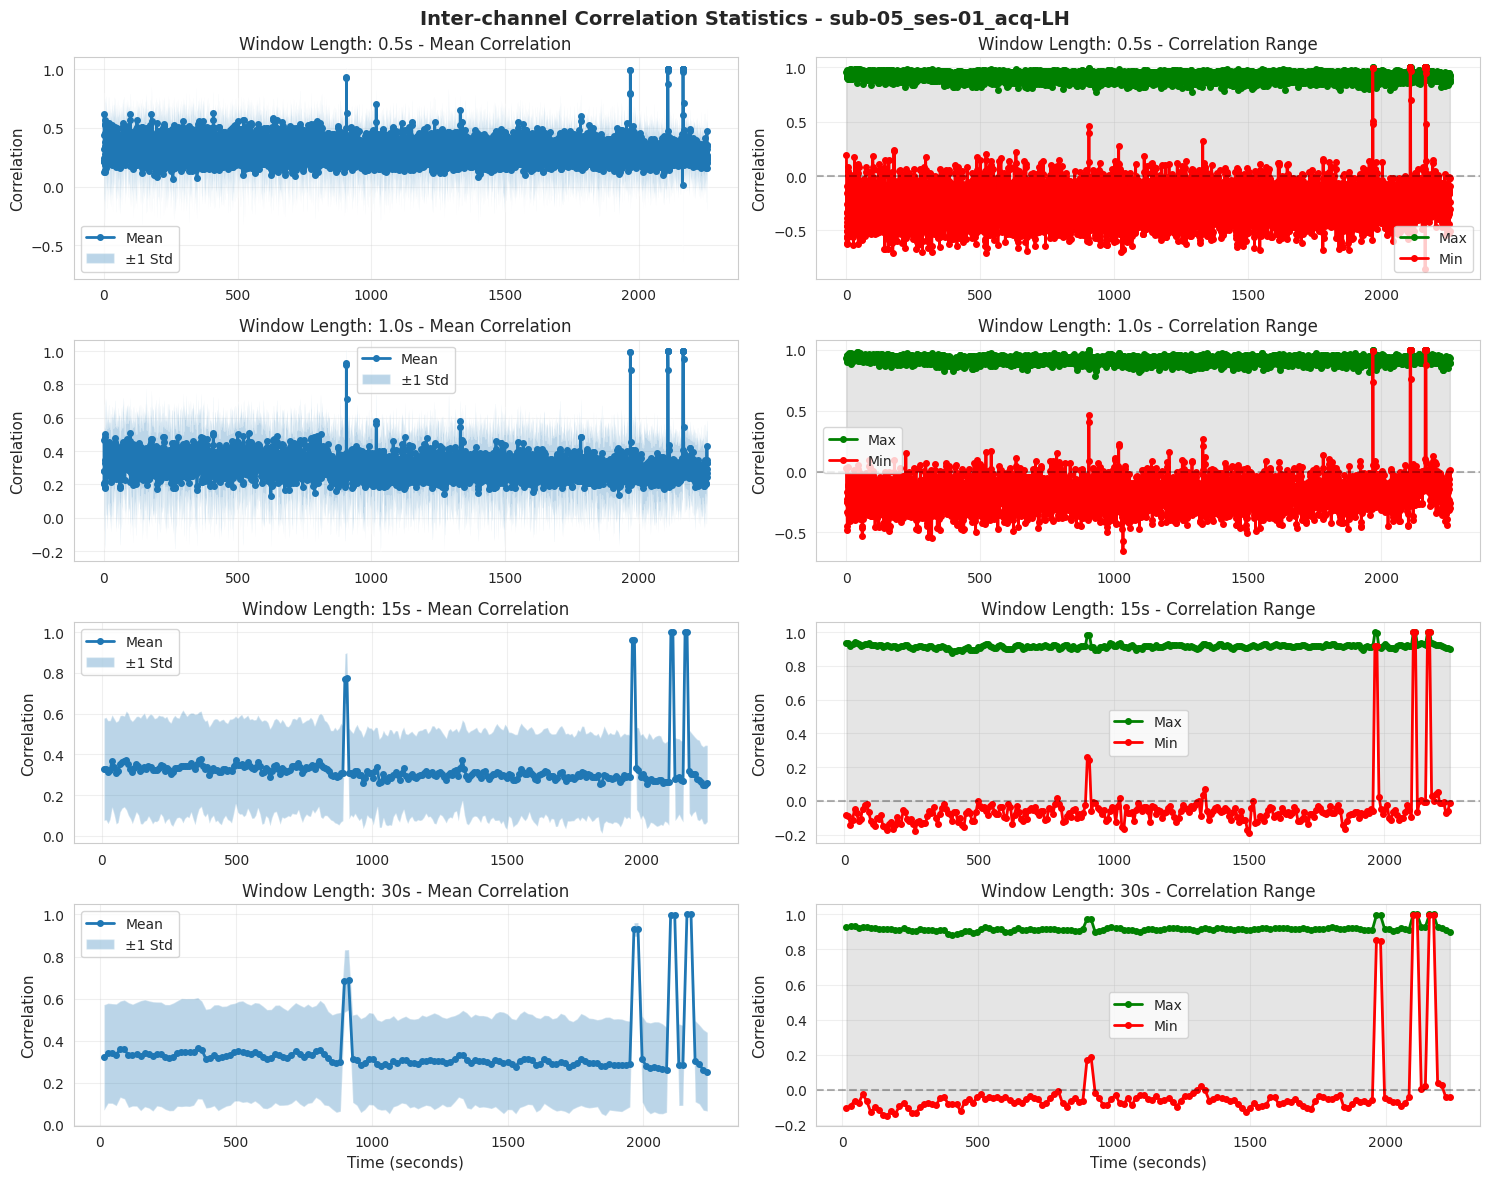

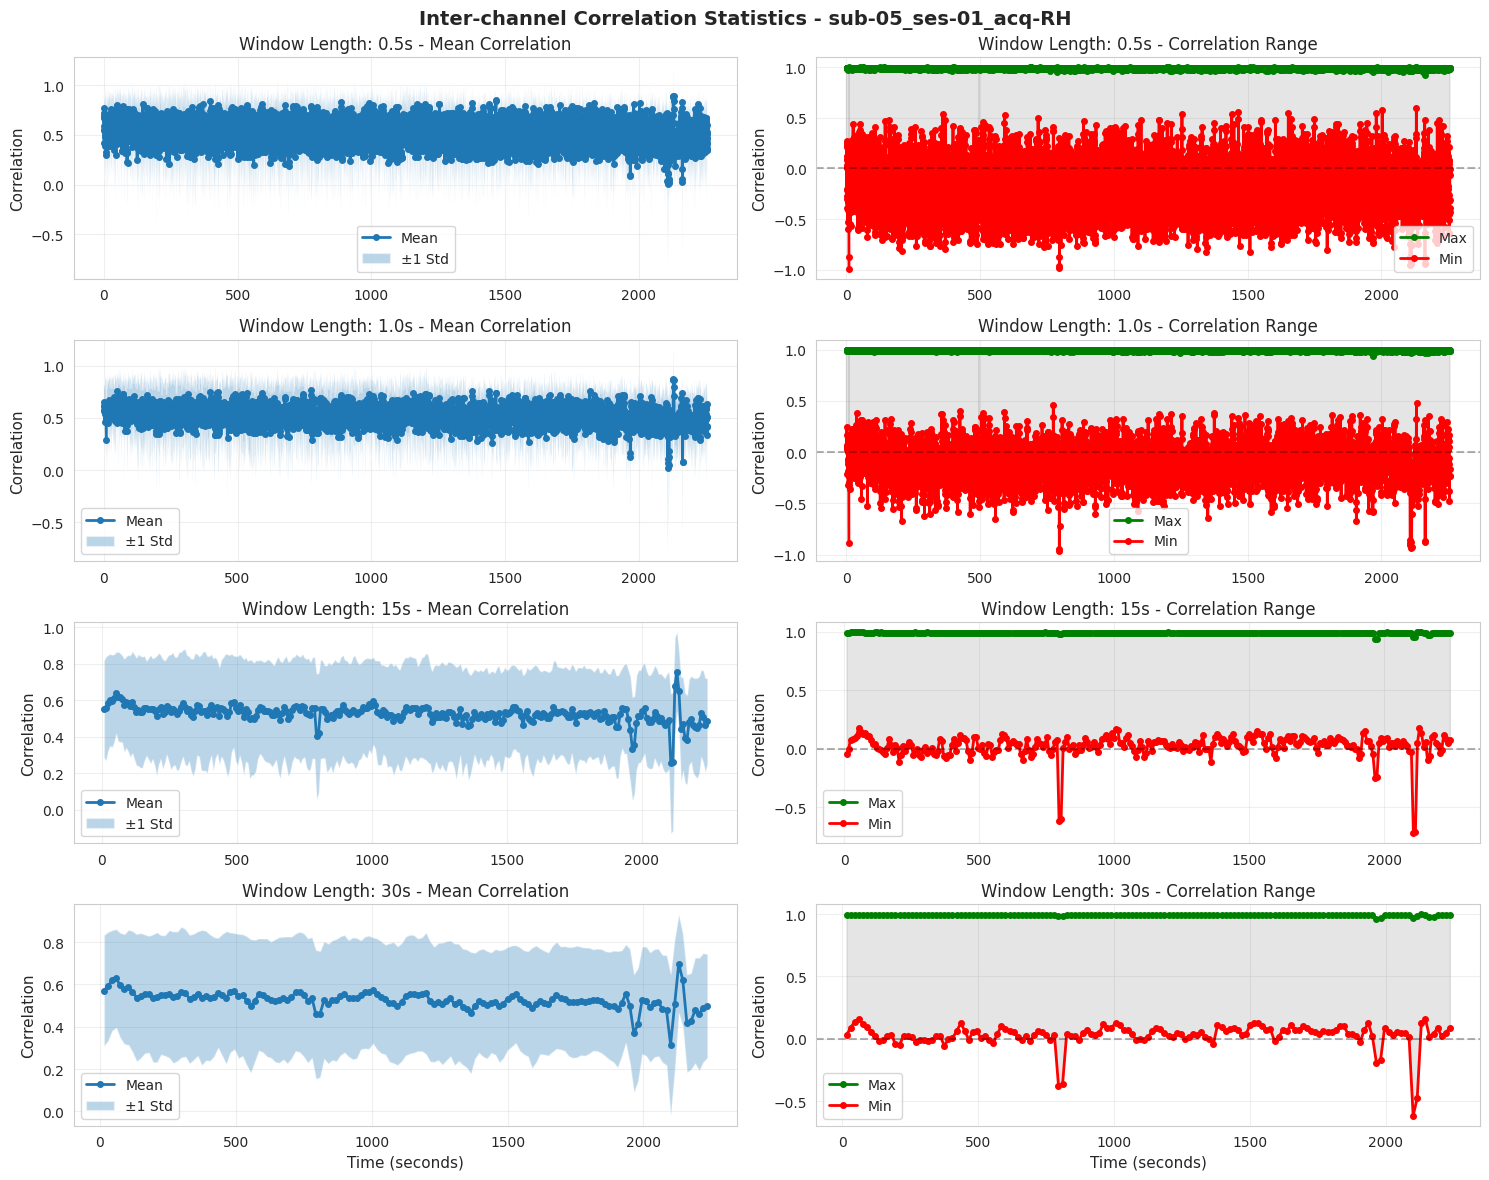

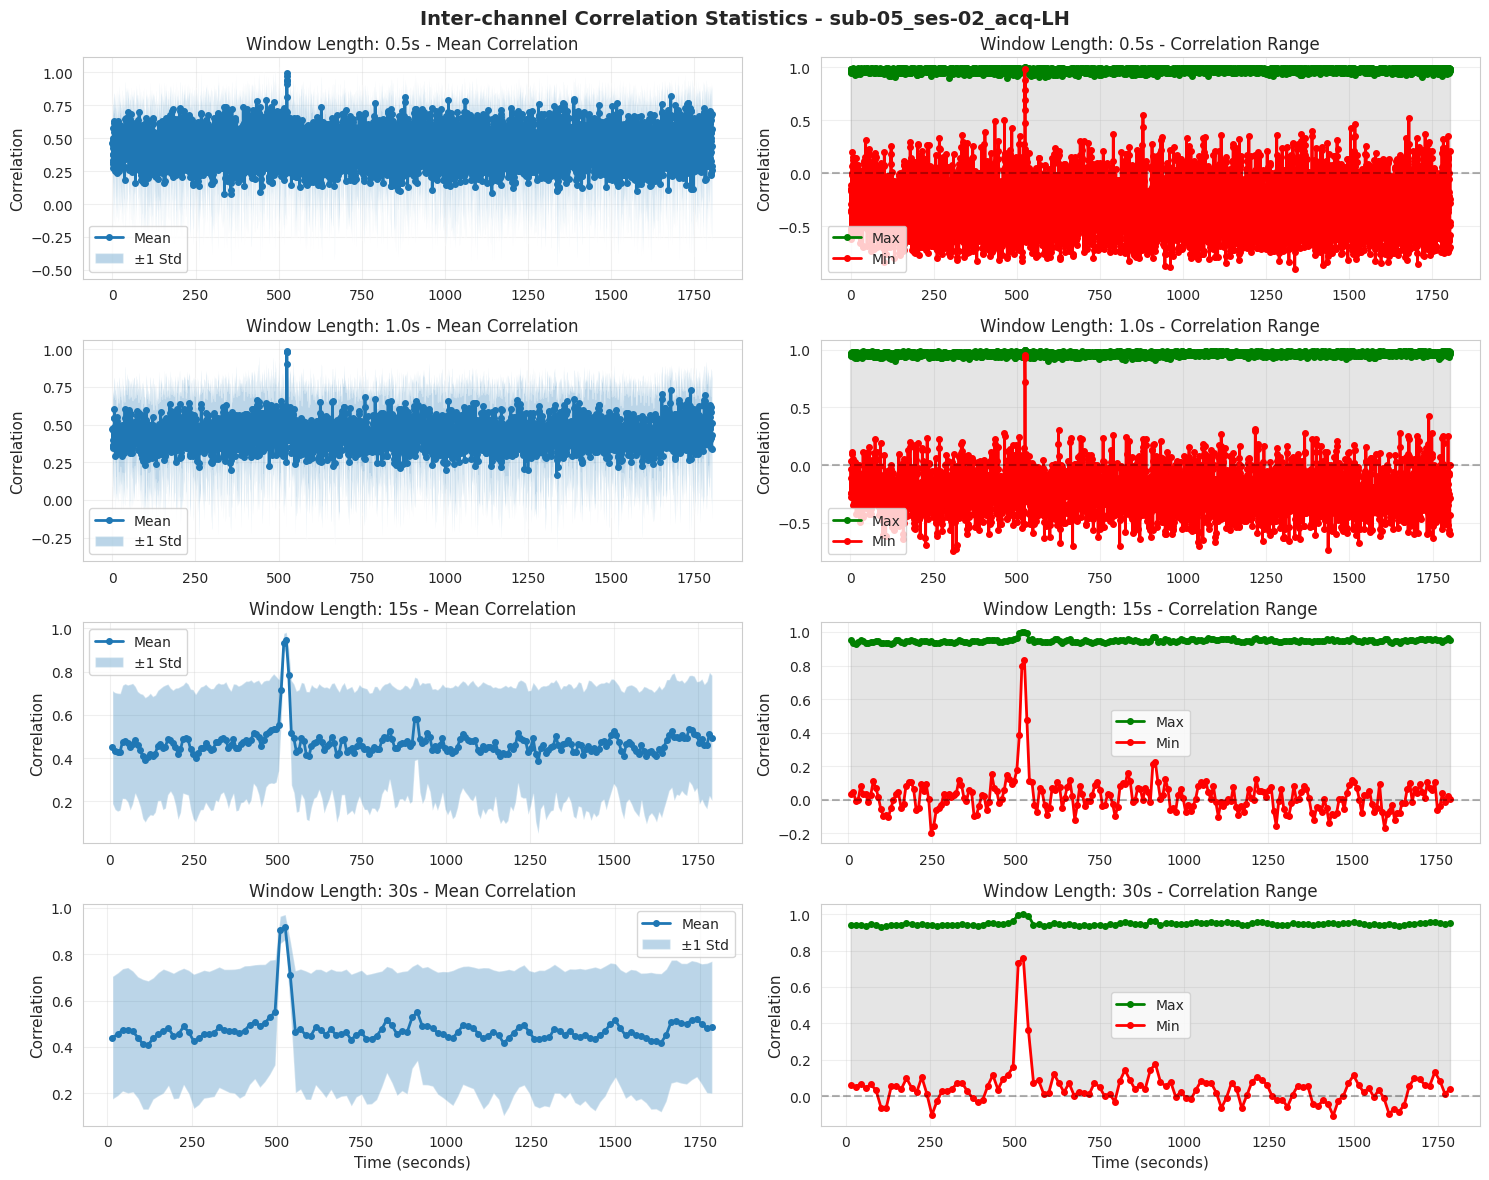

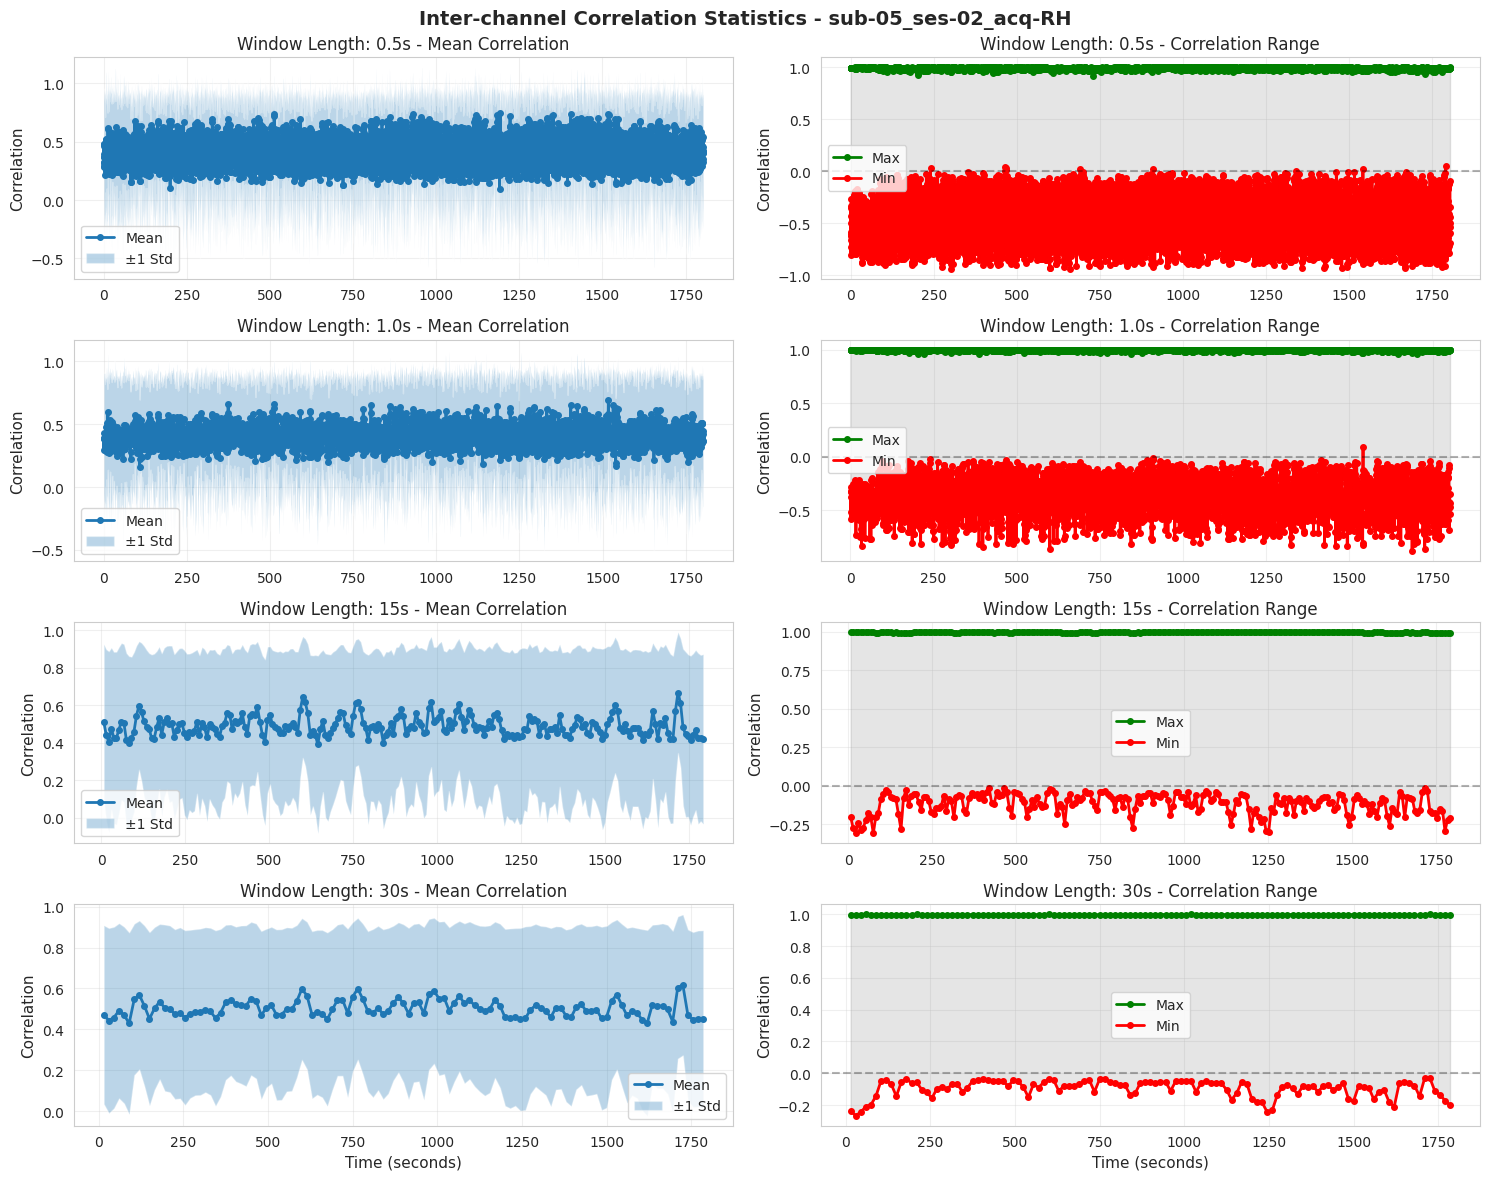

In [14]:
def plot_correlation_statistics(session_id, results_session):
    """
    Plot how correlation statistics change over time for different window lengths.
    """
    n_windows_max = max(r['n_windows'] for r in results_session.values())
    fig, axes = plt.subplots(len(window_lengths_seconds), 2, figsize=(15, 3*len(window_lengths_seconds)))
    
    if len(window_lengths_seconds) == 1:
        axes = axes.reshape(1, -1)
    
    for row, window_length in enumerate(sorted(window_lengths_seconds)):
        result = results_session[window_length]
        window_times = result['window_times']
        stats_data = result['stats']
        
        # Plot mean correlation with error bars
        ax = axes[row, 0]
        ax.plot(window_times, stats_data['mean_corr'], 'o-', linewidth=2, markersize=4, label='Mean')
        ax.fill_between(window_times, 
                        stats_data['mean_corr'] - stats_data['std_corr'],
                        stats_data['mean_corr'] + stats_data['std_corr'],
                        alpha=0.3, label='±1 Std')
        ax.set_ylabel('Correlation', fontsize=11)
        ax.set_title(f'Window Length: {window_length}s - Mean Correlation', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot min/max range
        ax = axes[row, 1]
        ax.plot(window_times, stats_data['max_corr'], 'o-', linewidth=2, markersize=4, label='Max', color='green')
        ax.plot(window_times, stats_data['min_corr'], 'o-', linewidth=2, markersize=4, label='Min', color='red')
        ax.fill_between(window_times, stats_data['min_corr'], stats_data['max_corr'], 
                       alpha=0.2, color='gray')
        ax.set_ylabel('Correlation', fontsize=11)
        ax.set_title(f'Window Length: {window_length}s - Correlation Range', fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    for ax in axes[-1, :]:
        ax.set_xlabel('Time (seconds)', fontsize=11)
    
    fig.suptitle(f'Inter-channel Correlation Statistics - {session_id}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Plot for each session
for session_id in sorted(results.keys()):
    plot_correlation_statistics(session_id, results[session_id])

## 5. Visualization: Correlation Matrices for Selected Windows

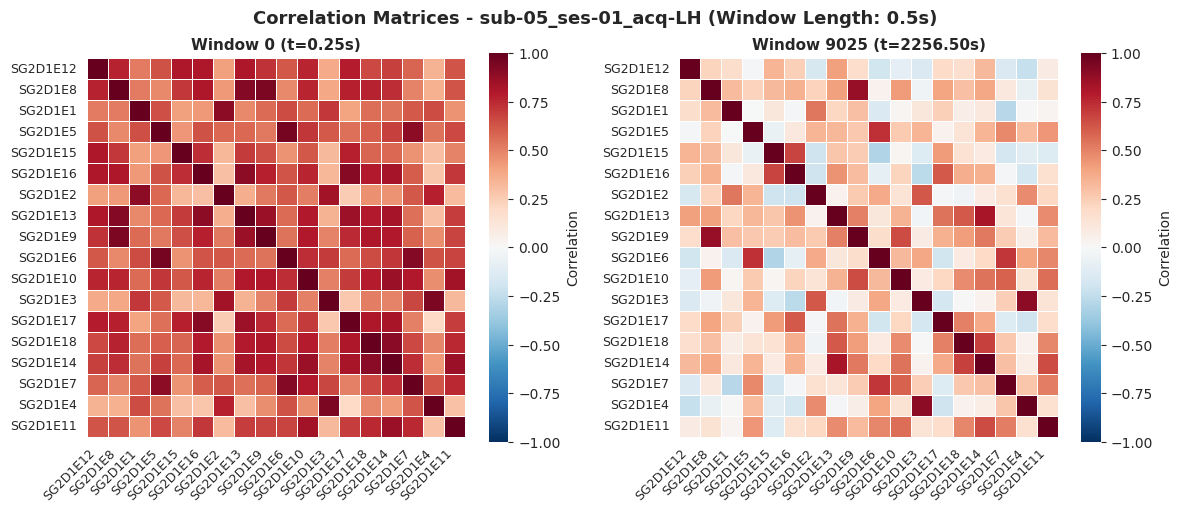

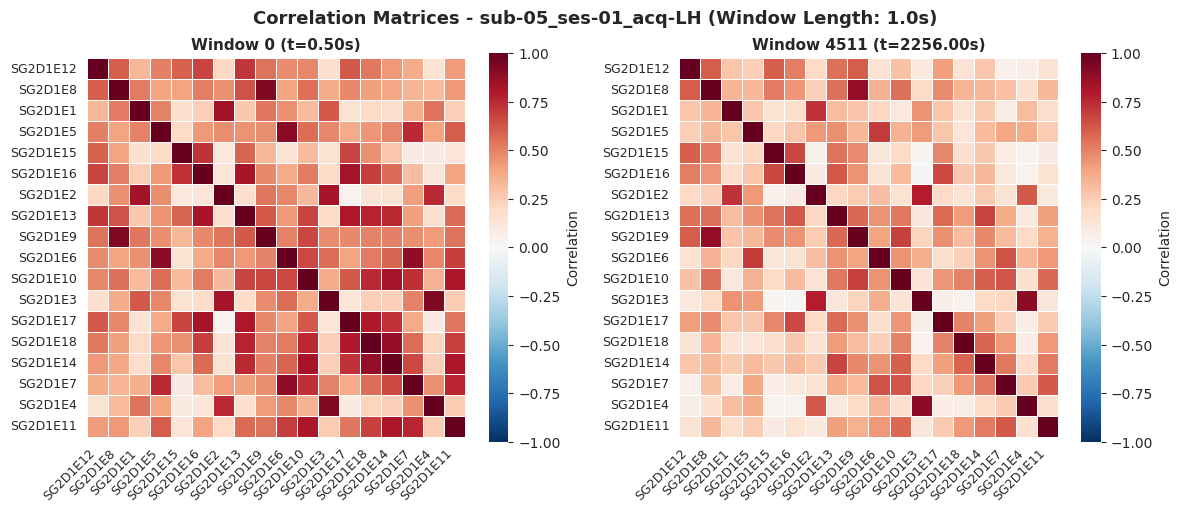

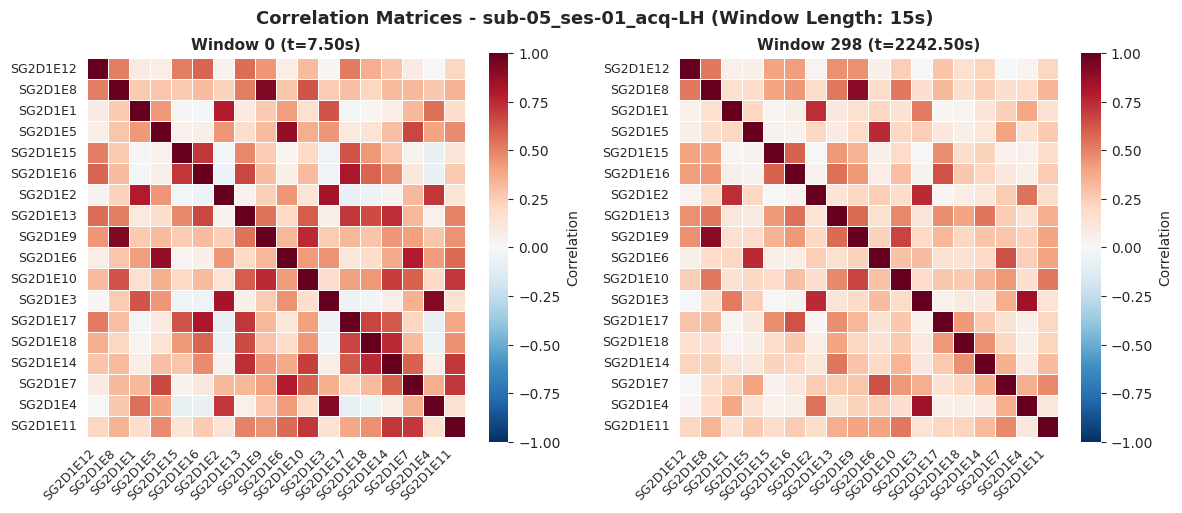

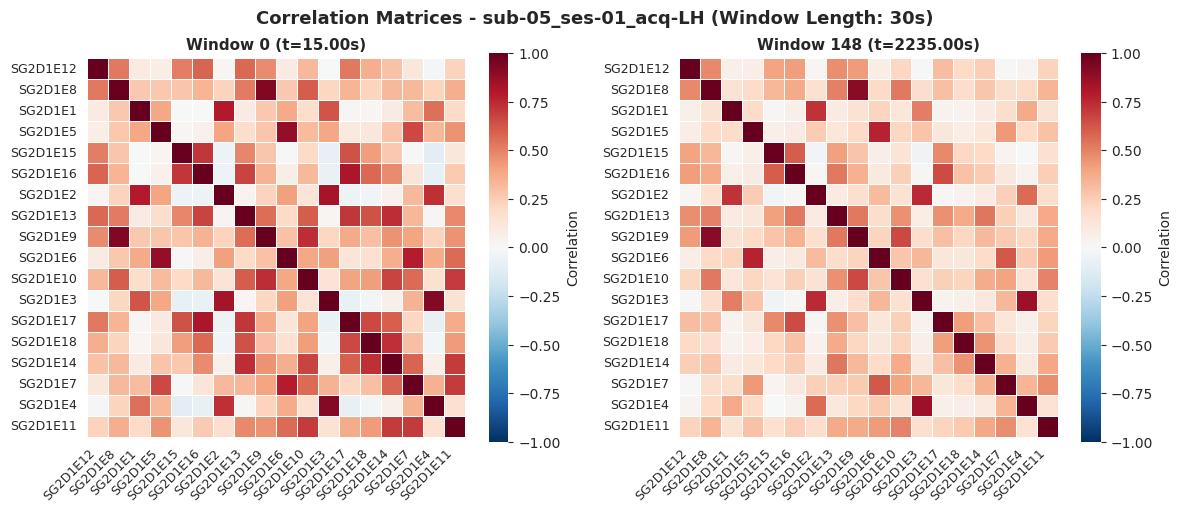

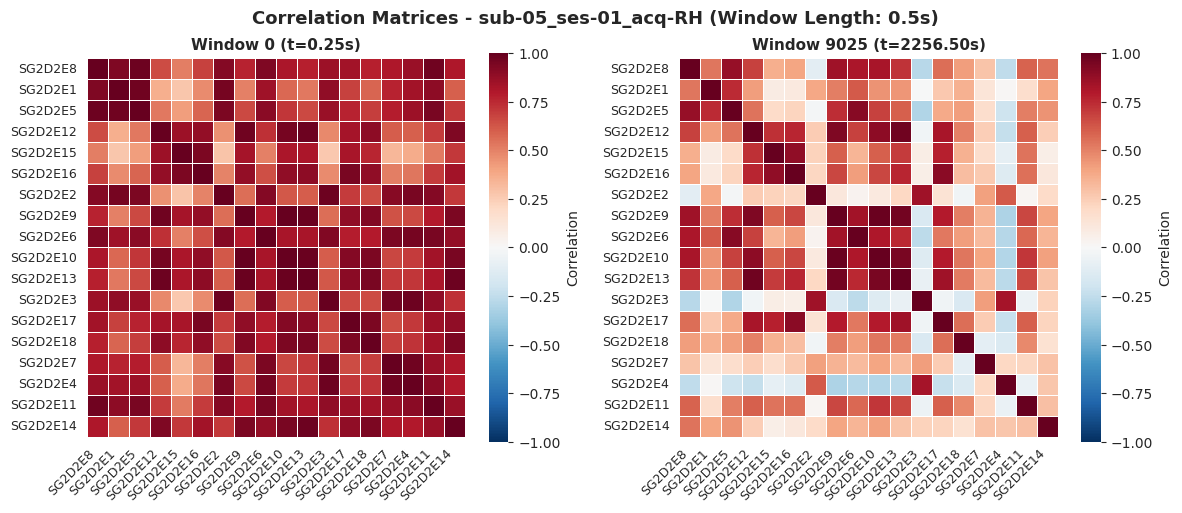

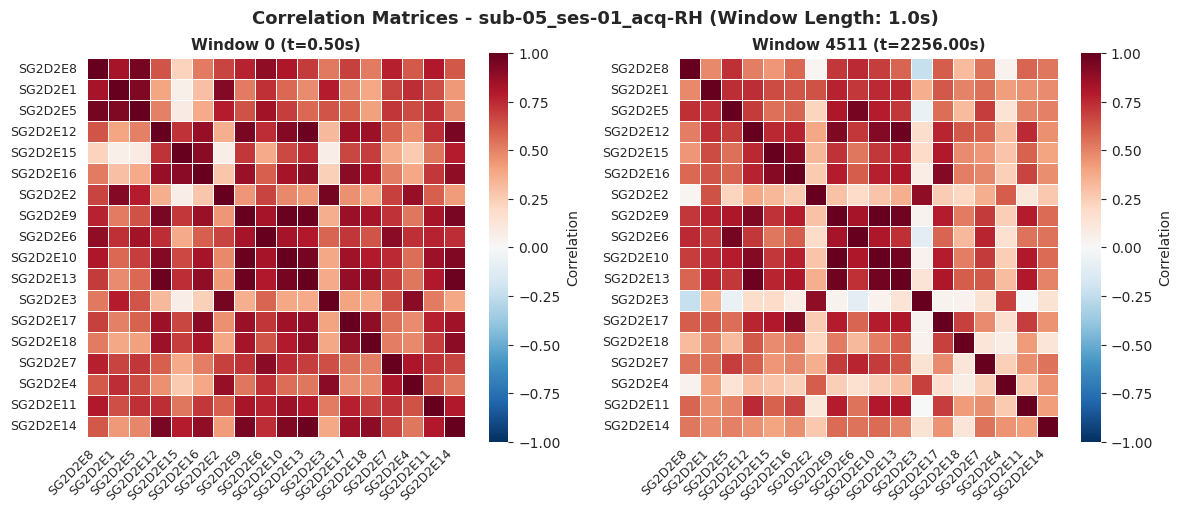

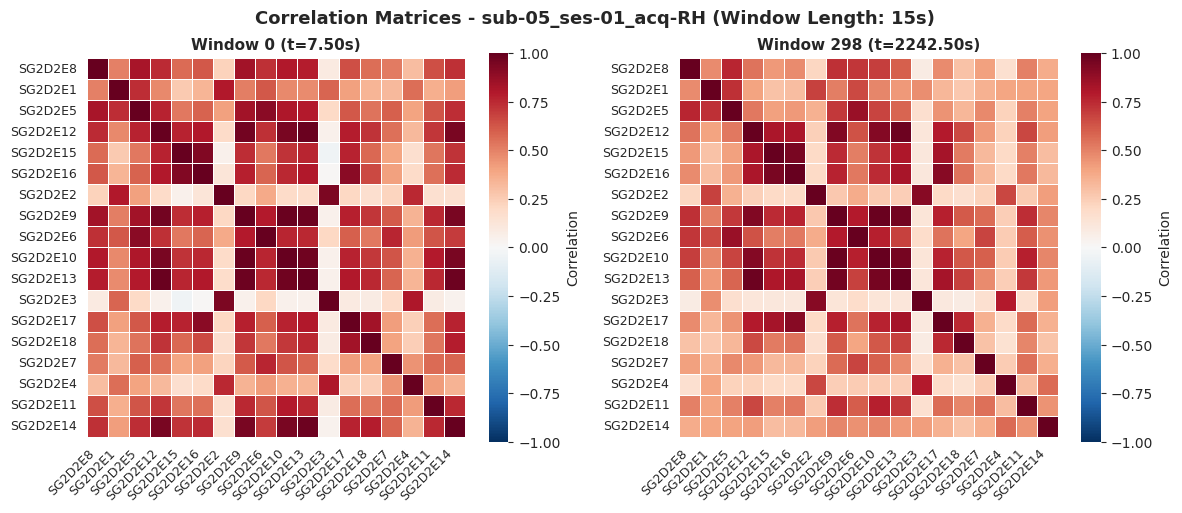

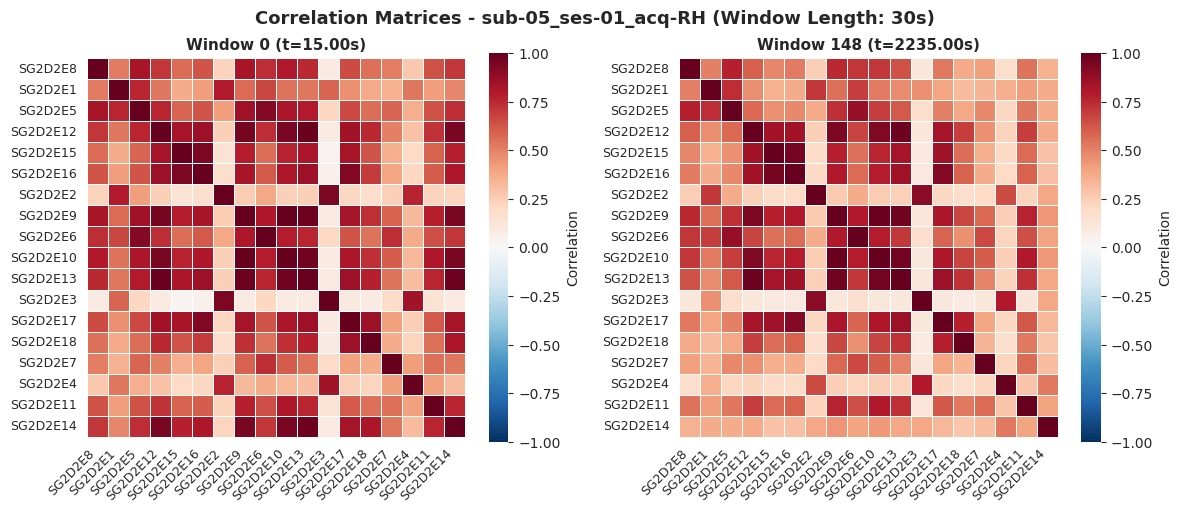

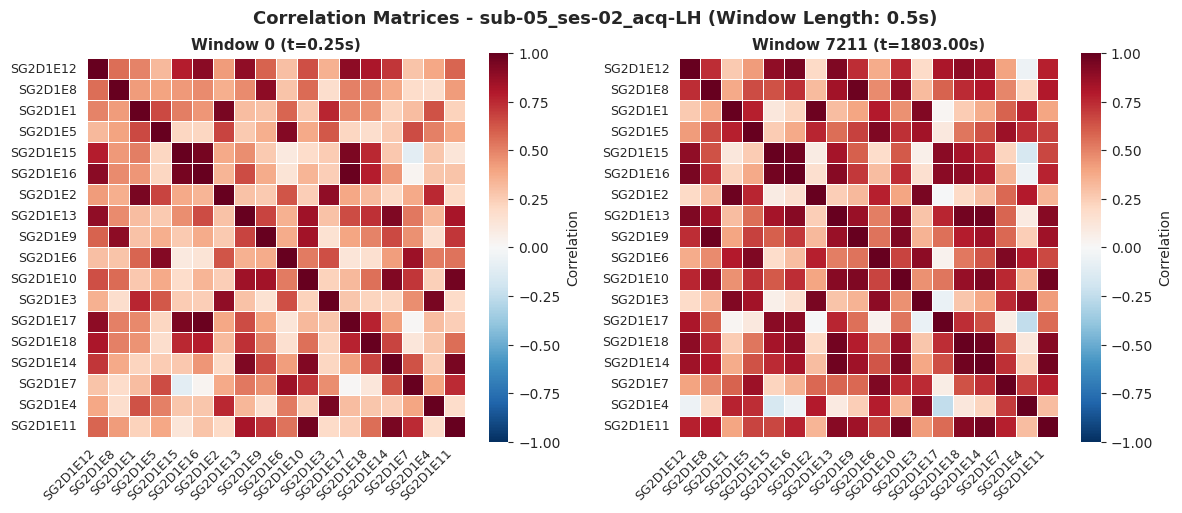

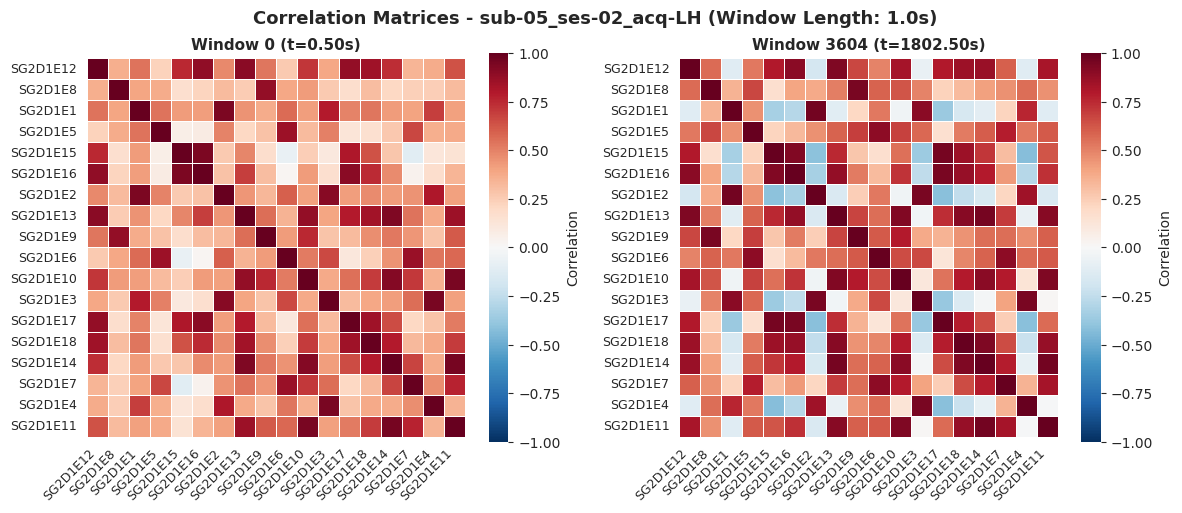

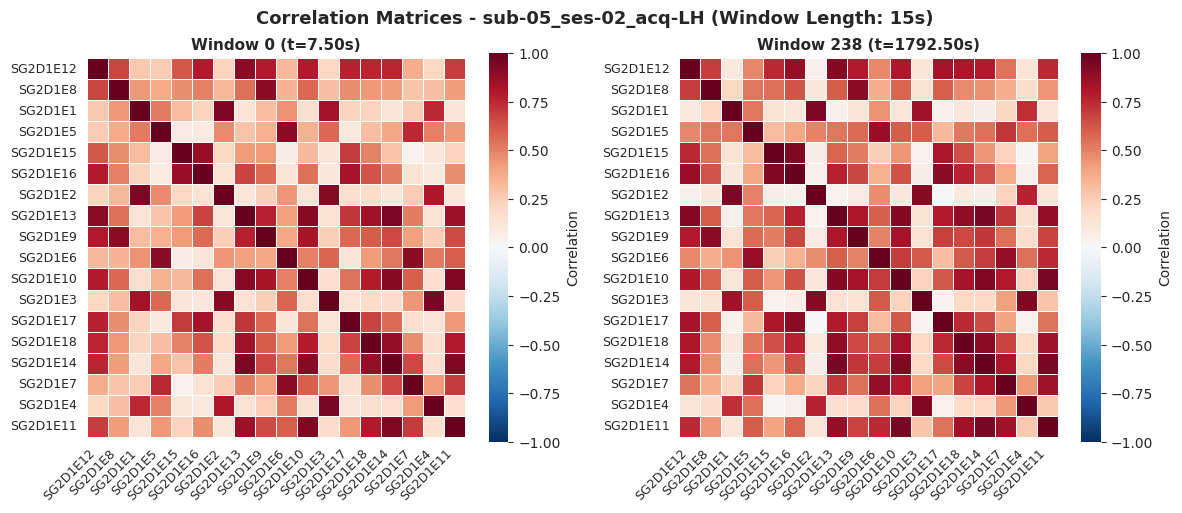

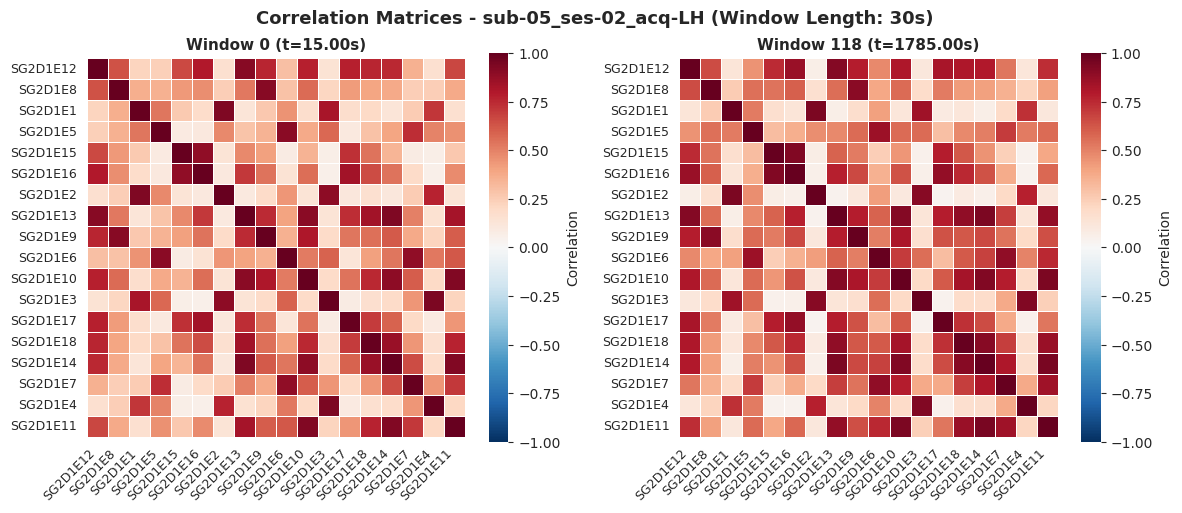

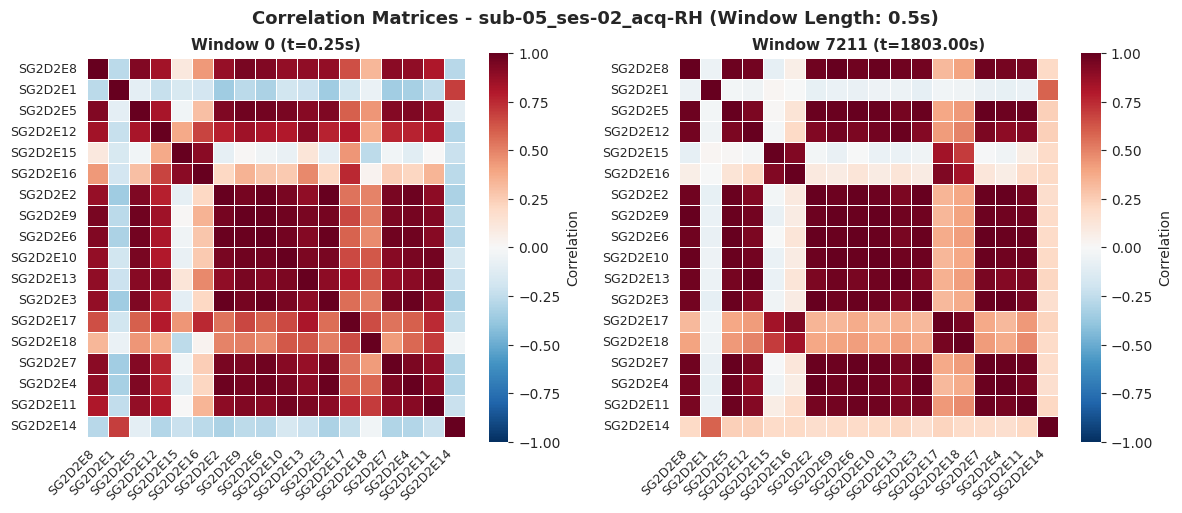

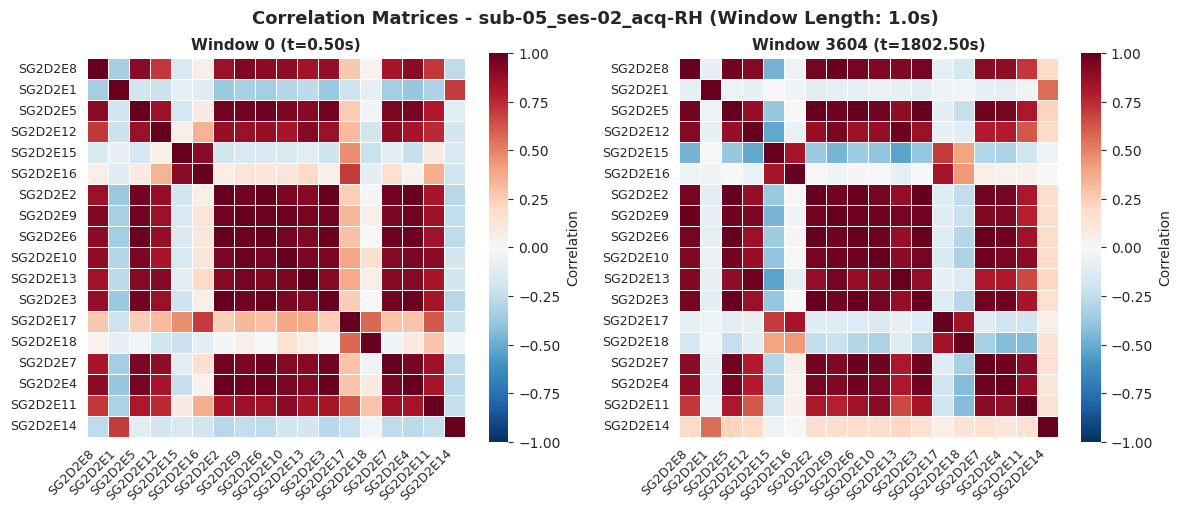

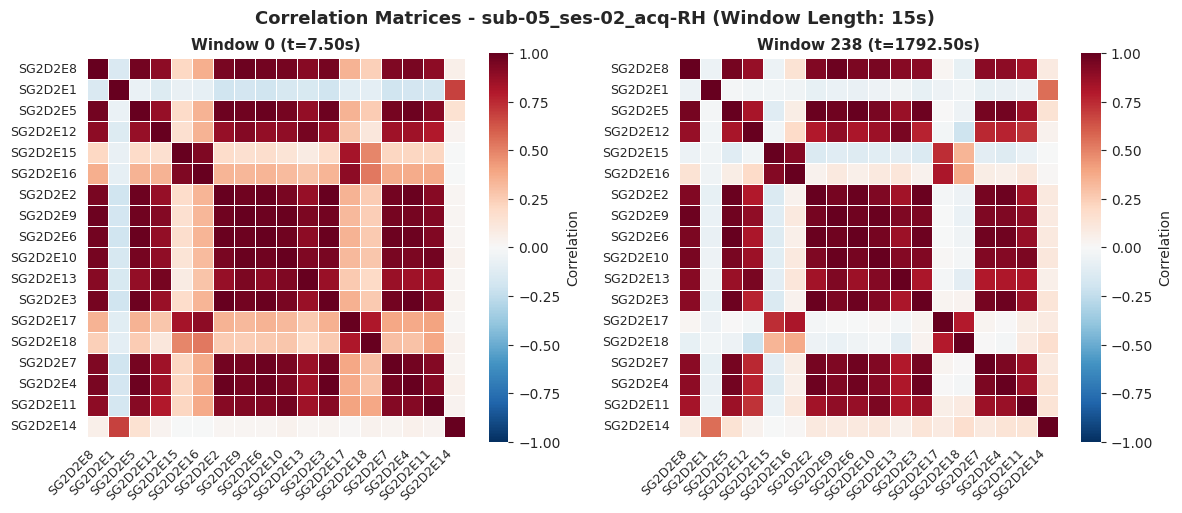

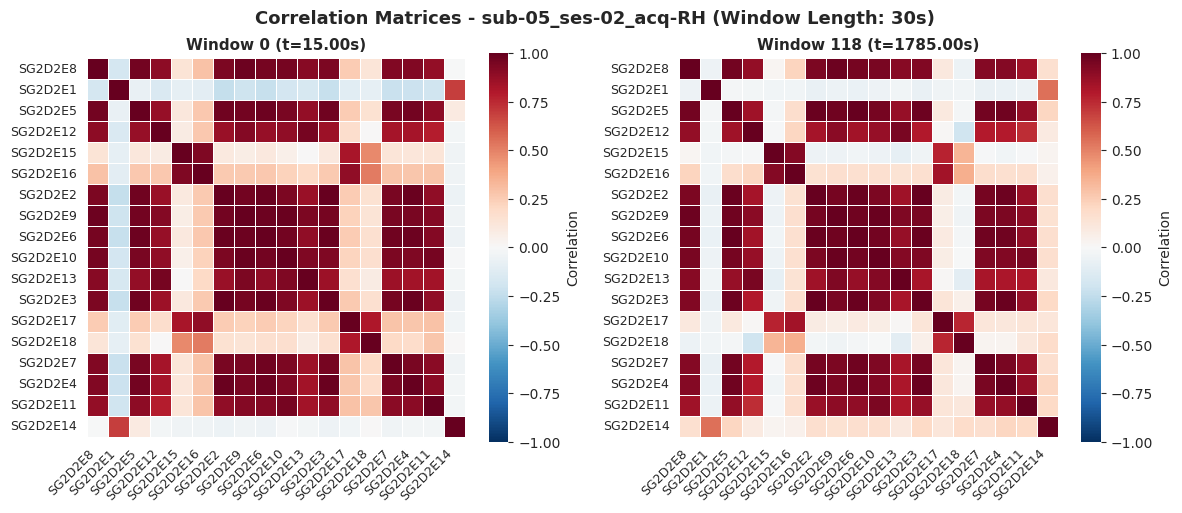

In [15]:
def plot_correlation_heatmaps(session_id, results_session, window_length, window_indices_to_plot=None):
    """
    Plot correlation matrices as heatmaps for selected windows using seaborn.
    
    Args:
        session_id: Session identifier
        results_session: Results dict for this session
        window_length: Which window length to visualize
        window_indices_to_plot: List of window indices to plot (e.g., [0, -1])
    """
    import seaborn as sns
    
    if window_indices_to_plot is None:
        window_indices_to_plot = [0, -1]
    
    result = results_session[window_length]
    correlations = result['correlations']
    channel_names = result['channel_names']
    window_times = result['window_times']
    n_channels = len(channel_names)
    
    # Filter out invalid indices
    valid_indices = [i if i >= 0 else len(correlations) + i for i in window_indices_to_plot]
    valid_indices = [i for i in valid_indices if 0 <= i < len(correlations)]
    
    n_plots = len(valid_indices)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    # Set up color norm for consistency across plots
    vmin, vmax = -1.0, 1.0
    
    for plot_idx, window_idx in enumerate(valid_indices):
        corr_matrix = correlations[window_idx]
        
        # Plot heatmap using seaborn
        ax = axes[plot_idx]
        sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=vmin, vmax=vmax,
                    xticklabels=channel_names, yticklabels=channel_names,
                    cbar_kws={'label': 'Correlation'}, square=True, ax=ax,
                    linewidths=0.5, linecolor='white', annot=False, fmt='.2f', annot_kws={'size': 8})
        
        window_time = window_times[window_idx]
        ax.set_title(f'Window {window_idx} (t={window_time:.2f}s)', fontsize=11, fontweight='bold')
        
        # Rotate labels for readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
    
    fig.suptitle(f'Correlation Matrices - {session_id} (Window Length: {window_length}s)', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


if plot_individual_correlations:
    for session_id in sorted(results.keys()):
        for window_length in sorted(window_lengths_seconds):
            plot_correlation_heatmaps(session_id, results[session_id], window_length, 
                                     window_indices_to_plot=selected_window_indices)

## 6. Comparative Analysis: How Window Length Affects Correlations

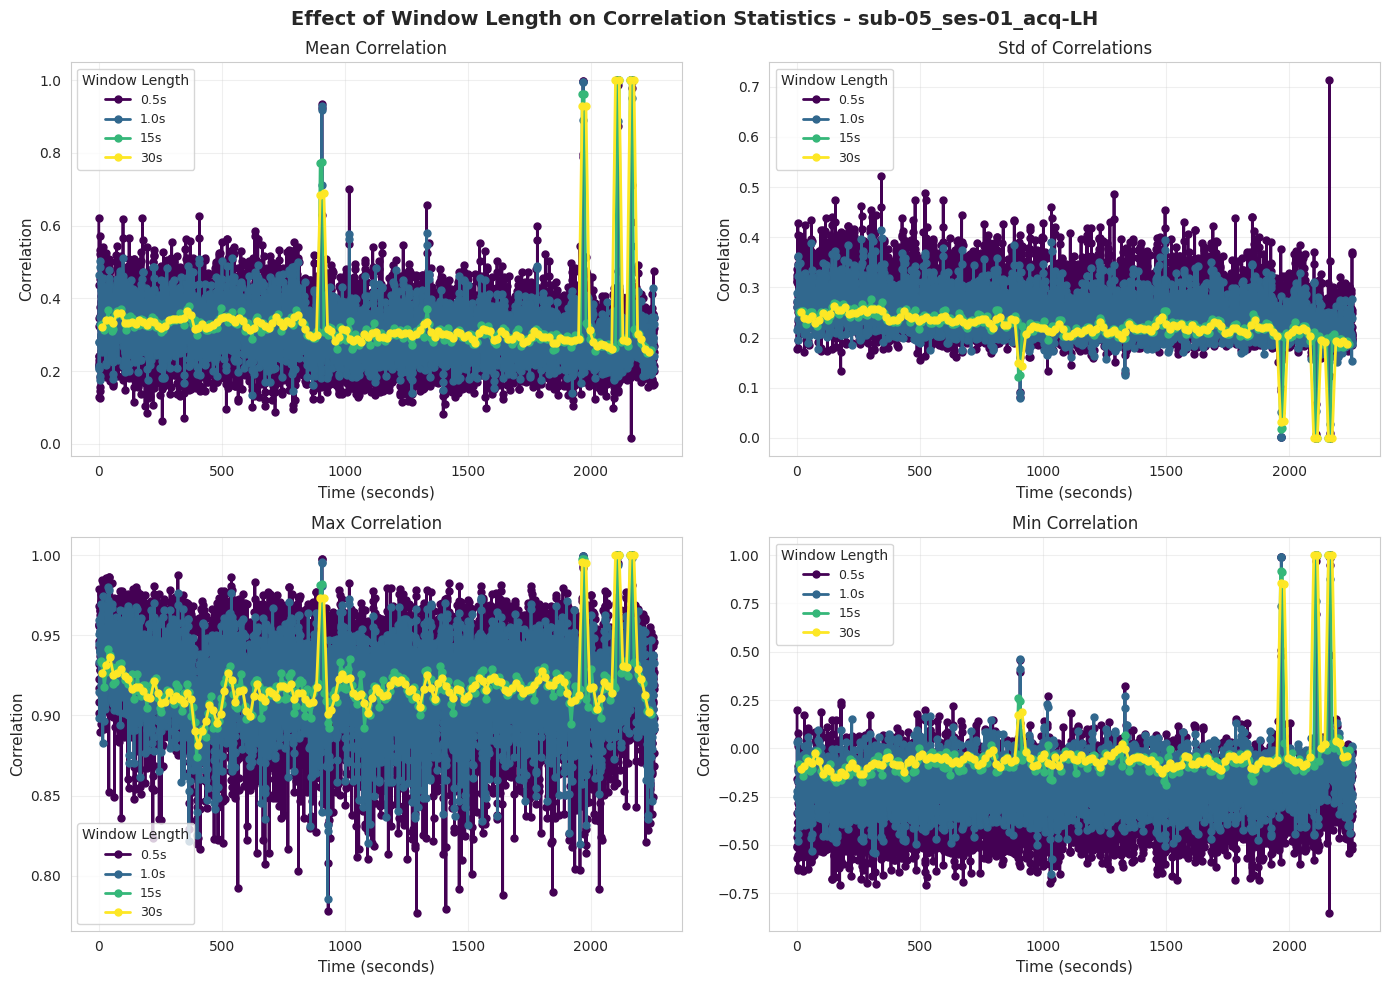

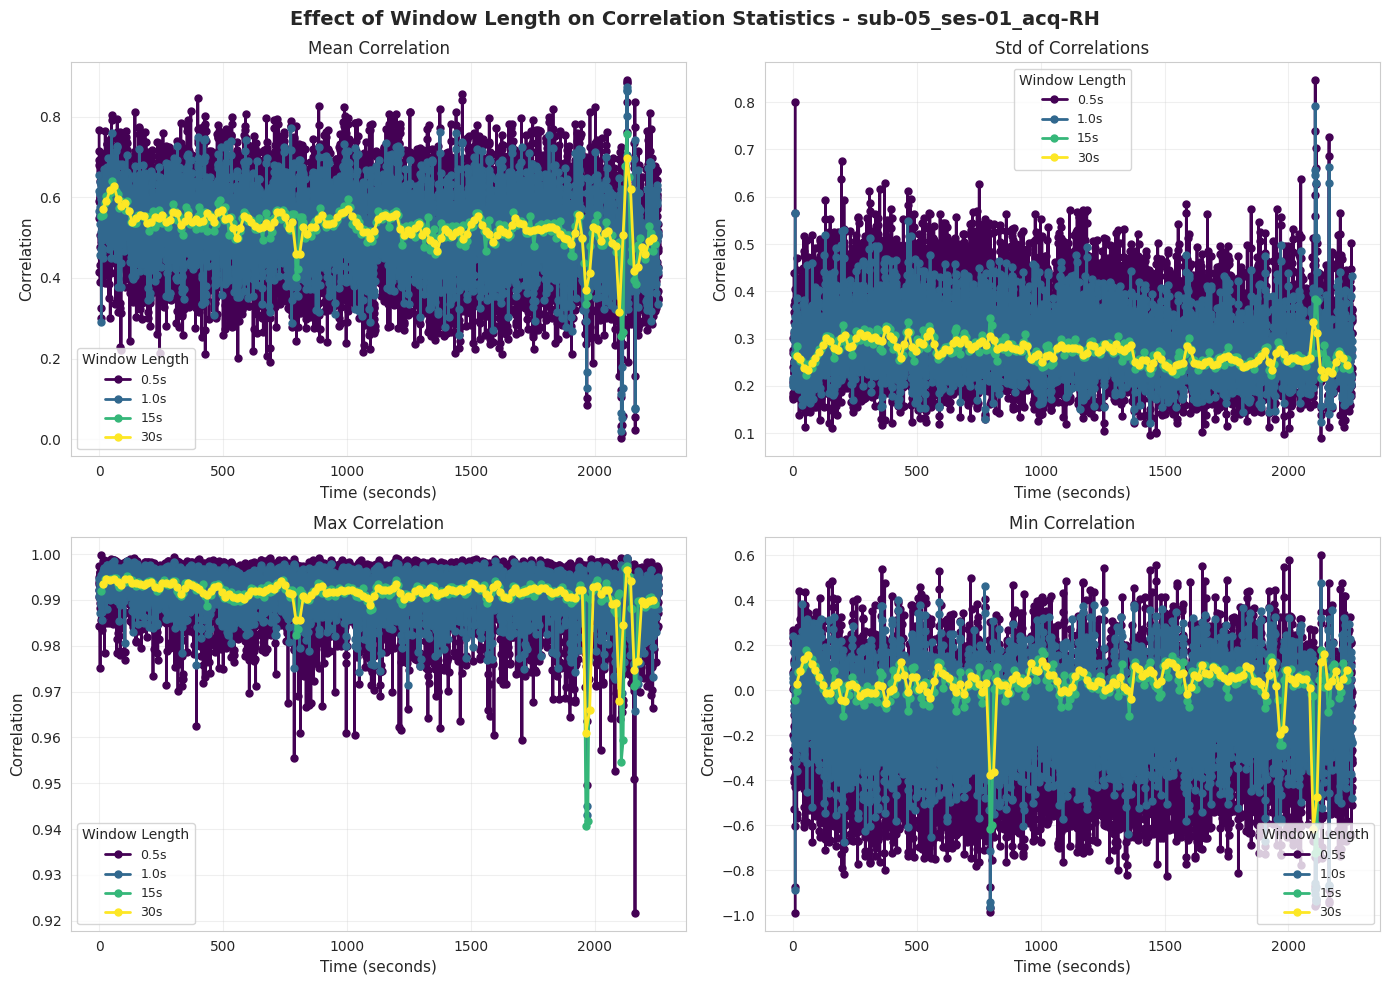

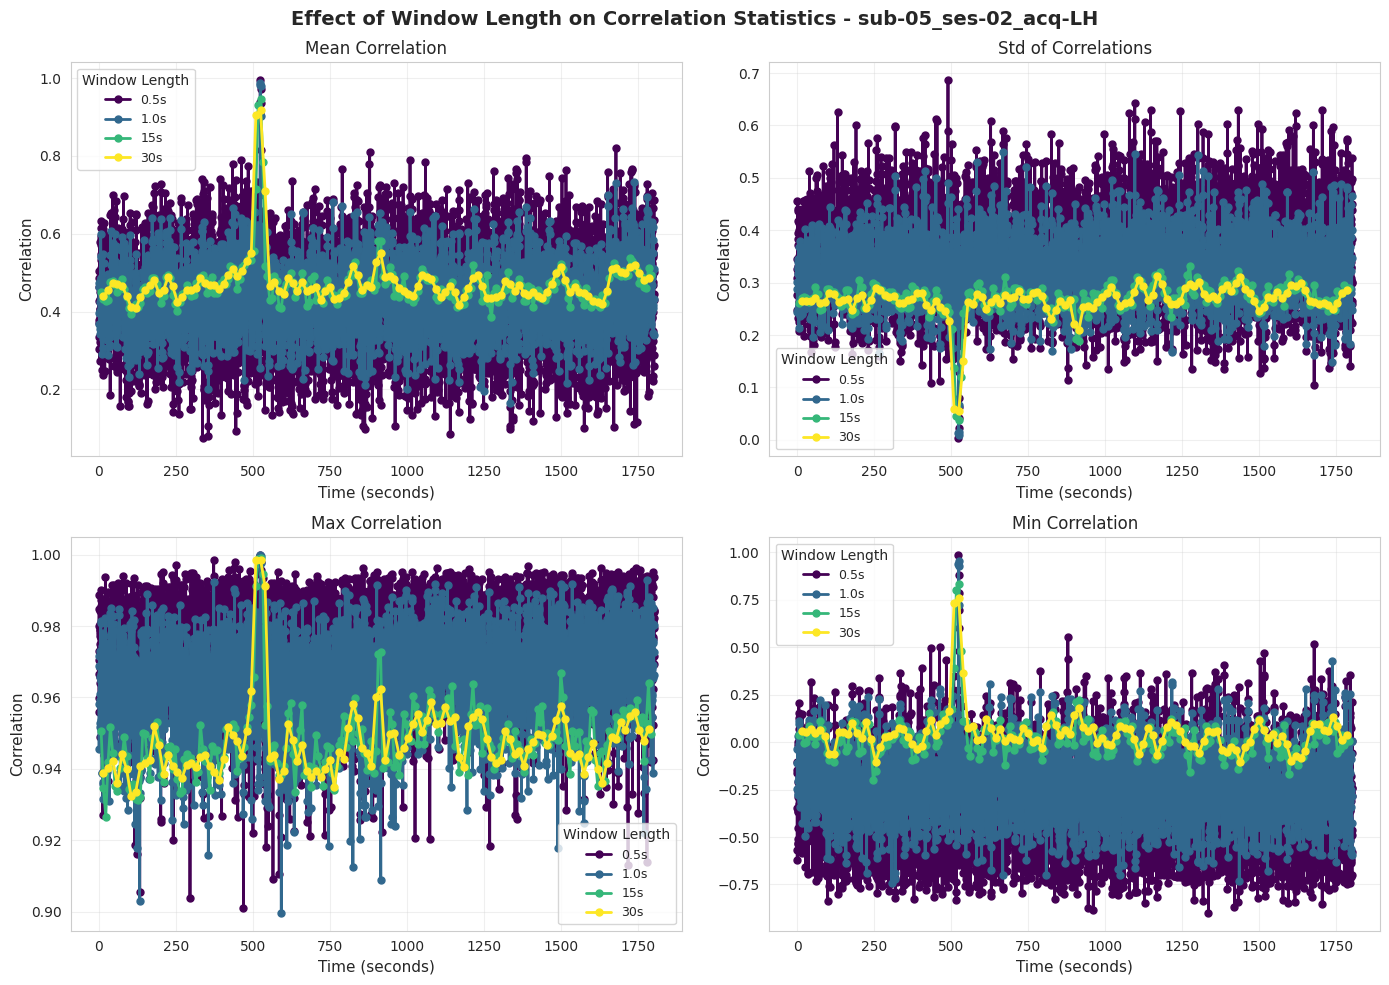

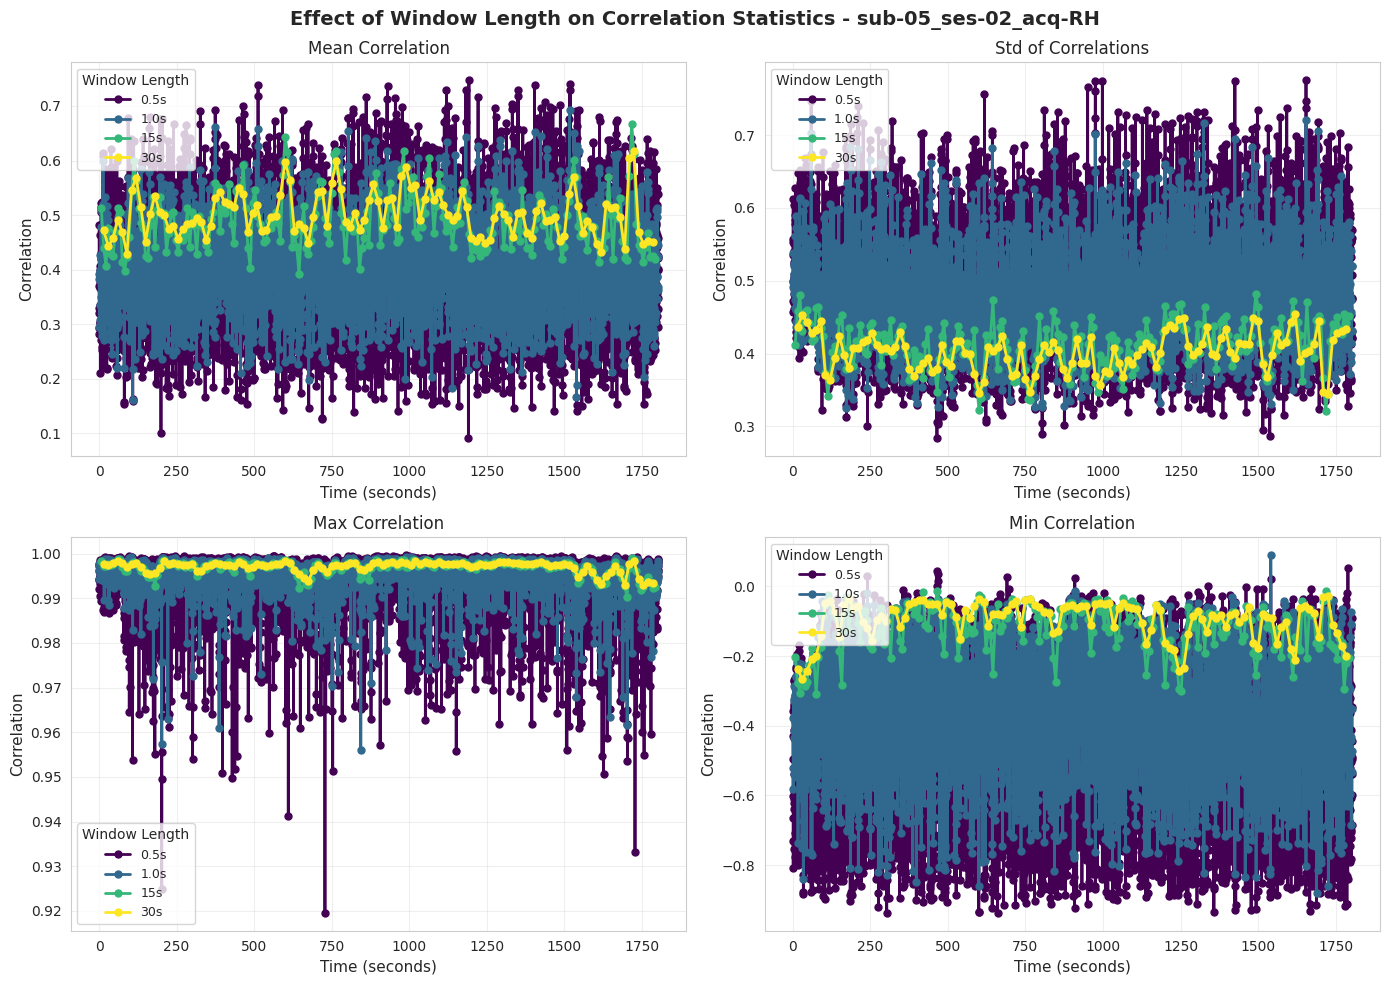

In [16]:
def plot_window_length_comparison(session_id, results_session):
    """
    Compare correlation statistics across different window lengths.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = ['mean_corr', 'std_corr', 'max_corr', 'min_corr']
    titles = ['Mean Correlation', 'Std of Correlations', 'Max Correlation', 'Min Correlation']
    colors = plt.cm.viridis(np.linspace(0, 1, len(window_lengths_seconds)))
    
    for ax, metric, title in zip(axes.flat, metrics, titles):
        for color, window_length in zip(colors, sorted(window_lengths_seconds)):
            result = results_session[window_length]
            window_times = result['window_times']
            stats_data = result['stats']
            
            ax.plot(window_times, stats_data[metric], 'o-', label=f"{window_length}s", 
                   linewidth=2, markersize=5, color=color)
        
        ax.set_xlabel('Time (seconds)', fontsize=11)
        ax.set_ylabel('Correlation', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.legend(title='Window Length', fontsize=9, title_fontsize=10)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'Effect of Window Length on Correlation Statistics - {session_id}', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


for session_id in sorted(results.keys()):
    plot_window_length_comparison(session_id, results[session_id])

## 7. Summary Statistics Across All Sessions

In [17]:
# Create a summary table of correlation statistics
summary_data = []

for session_id in sorted(results.keys()):
    for window_length in sorted(window_lengths_seconds):
        result = results[session_id][window_length]
        stats_data = result['stats']
        
        summary_data.append({
            'Session': session_id,
            'Window Length (s)': window_length,
            'N Windows': result['n_windows'],
            'Mean Corr (μ)': np.mean(stats_data['mean_corr']),
            'Mean Corr (σ)': np.std(stats_data['mean_corr']),
            'Std Corr (μ)': np.mean(stats_data['std_corr']),
            'Std Corr (σ)': np.std(stats_data['std_corr']),
        })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Statistics:")
print(summary_df.to_string(index=False))


Summary Statistics:
             Session  Window Length (s)  N Windows  Mean Corr (μ)  Mean Corr (σ)  Std Corr (μ)  Std Corr (σ)
sub-05_ses-01_acq-LH                0.5       9026       0.302949       0.086996      0.265475      0.049514
sub-05_ses-01_acq-LH                1.0       4512       0.309444       0.074123      0.247519      0.039196
sub-05_ses-01_acq-LH               15.0        299       0.326731       0.105101      0.221198      0.036509
sub-05_ses-01_acq-LH               30.0        149       0.342571       0.138907      0.216128      0.045898
sub-05_ses-01_acq-RH                0.5       9026            NaN            NaN           NaN           NaN
sub-05_ses-01_acq-RH                1.0       4512            NaN            NaN           NaN           NaN
sub-05_ses-01_acq-RH               15.0        299       0.527656       0.047527      0.272950      0.025652
sub-05_ses-01_acq-RH               30.0        149       0.527578       0.041769      0.271811      0.02216

## 8. Interactive Exploration (Optional)

In [18]:
# This cell allows for flexible exploration of specific windows and correlations
# Uncomment and modify as needed for deeper analysis

# Example: Get all correlations from a specific session and window length
# session_id = 'sub-03_ses-01'
# window_length = 2.0
# result = results[session_id][window_length]
# correlations = result['correlations']
# channel_names = result['channel_names']
# 
# # Example: Find the window with maximum mean correlation
# mean_corrs = [np.mean(np.triu(c, k=1)) for c in correlations]
# max_window_idx = np.argmax(mean_corrs)
# print(f"Window with max mean correlation: {max_window_idx} (value: {mean_corrs[max_window_idx]:.3f})")
# 
# # Example: Compare specific channel pairs across windows
# ch1, ch2 = 0, 1
# channel_pair_corrs = [c[ch1, ch2] for c in correlations]
# plt.figure(figsize=(12, 4))
# plt.plot(result['window_times'], channel_pair_corrs, 'o-', linewidth=2)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Correlation')
# plt.title(f'Correlation between {channel_names[ch1]} and {channel_names[ch2]}')
# plt.grid(True, alpha=0.3)
# plt.show()

print("Interactive exploration cell ready. Uncomment and modify code as needed.")

Interactive exploration cell ready. Uncomment and modify code as needed.


## 9. Interactive Exploration (Optional)

In [19]:
# Flexible exploration of specific windows and correlations
# Uncomment and modify as needed

# Example: Find windows with most different correlation structures
# session_id = 'sub-03_ses-01'
# window_length = 2.0
# meta_corr = meta_corr_results[session_id][window_length]['meta_corr_matrix']
# meta_corr_copy = meta_corr.copy()
# np.fill_diagonal(meta_corr_copy, np.nan)
# min_corr_idx = np.unravel_index(np.nanargmin(meta_corr_copy), meta_corr.shape)
# print(f"Windows with most different structures: {min_corr_idx} (value: {meta_corr[min_corr_idx]:.3f})")

# Example: Compare specific channel pairs across windows
# ch1, ch2 = 0, 1
# channel_pair_corrs = [c[ch1, ch2] for c in results[session_id][window_length]['correlations']]
# window_times = results[session_id][window_length]['window_times']
# plt.plot(window_times, channel_pair_corrs, 'o-', linewidth=2)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Correlation')
# plt.title(f'Channel Pair Correlation Over Time')
# plt.grid(True, alpha=0.3)
# plt.show()

print("Exploration ready - uncomment examples above")

Exploration ready - uncomment examples above
